<a href="https://colab.research.google.com/github/NOUZHAK/code-taux-de-d-faut/blob/main/PDtests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""Alltests.ipynb — VERSION CORRIGÉE

PFE — Modélisation du Risque de Crédit
Attijari Titrisation — 3 Modèles x 3 Situations + LSTM + Ensemble
"""

# ##############################################################################
# CELLULE 0 — FIX AFFICHAGE MATPLOTLIB COLAB (à exécuter EN PREMIER)
# ##############################################################################

import IPython
try:
    IPython.get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import pickle, os

def sauver_etat(nom="dernier"):
    checkpoint = {}
    vars_a_sauver = [
        'df_model', 'df_avant',
        'FEATURES_NUM', 'FEATURES_CAT', 'TARGET',
        'idx_train', 'idx_val', 'idx_test',
        'resultats_all', 'champions_finaux',
        'COUT_FN_MAD', 'COUT_FP_MAD',
        'RANDOM_STATE',
    ]
    for v in vars_a_sauver:
        if v in globals():
            checkpoint[v] = globals()[v]
    chemin = DRIVE + f"checkpoint_{nom}.pkl"
    with open(chemin, "wb") as f:
        pickle.dump(checkpoint, f)
    print(f"  ✔ Checkpoint '{nom}' sauvé ({len(checkpoint)} variables) → {chemin}")

def charger_etat(nom="dernier"):
    chemin = DRIVE + f"checkpoint_{nom}.pkl"
    if not os.path.exists(chemin):
        print(f"  ❌ Checkpoint '{nom}' introuvable")
        return False
    with open(chemin, "rb") as f:
        checkpoint = pickle.load(f)
    for nom_var, valeur in checkpoint.items():
        globals()[nom_var] = valeur
    print(f"  ✔ Checkpoint '{nom}' chargé ({len(checkpoint)} variables)")
    return True

print("  ✔ Système checkpoint prêt")
print("     Usage : sauver_etat('apres_bloc11b')  /  charger_etat('apres_bloc11b')")

  ✔ Système checkpoint prêt
     Usage : sauver_etat('apres_bloc11b')  /  charger_etat('apres_bloc11b')


In [ ]:
# ##############################################################################
# BLOC 1 — MONTAGE GOOGLE DRIVE + INSTALLATION DES LIBRAIRIES
# ##############################################################################

from google.colab import drive
drive.mount('/content/drive')

import subprocess, os

subprocess.run(["pip", "install", "-q",
                "imbalanced-learn", "xgboost",
                "openpyxl", "joblib", "shap", "lime"], check=True)

DRIVE = "/content/drive/MyDrive/data_PFE/"

fichiers_requis = ["baseclient.xlsx", "Historique.parquet"]
for f in fichiers_requis:
    existe = os.path.exists(DRIVE + f)
    print(f"  {'✔' if existe else '✗'} {f}")

n_supprimes = 0
for f in os.listdir(DRIVE):
    if f.endswith(".png"):
        if os.path.getsize(DRIVE + f) < 5000:
            os.remove(DRIVE + f)
            n_supprimes += 1

print(f"\n  ✔ Drive monté")
print(f"  ✔ Librairies installées")
if n_supprimes > 0:
    print(f"  ✔ {n_supprimes} fichier(s) temporaire(s) nettoyé(s)")

Mounted at /content/drive
  ✔ baseclient.xlsx
  ✔ Historique.parquet

  ✔ Drive monté
  ✔ Librairies installées


In [ ]:
# ##############################################################################
# BLOC 2 — IMPORTS ET PARAMÈTRES GLOBAUX
# ##############################################################################

import matplotlib
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

plt.rcParams.update({
    'figure.dpi'       : 110,
    'figure.facecolor' : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

import seaborn as sns
import os, sys, warnings, joblib
import pandas as pd
import numpy as np
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score,
    brier_score_loss, fbeta_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
    print("✔ XGBoost disponible")
except ImportError:
    XGBOOST_OK = False
    print("⚠ XGBoost non disponible")

warnings.filterwarnings("ignore")
print(f"✔ Imports OK — Backend Matplotlib : {matplotlib.get_backend()}")

DRIVE              = "/content/drive/MyDrive/data_PFE/"
FICHIER_SNAPSHOT   = DRIVE + "baseclient.xlsx"
FICHIER_HISTORIQUE = DRIVE + "Historique.parquet"

SNAPSHOT_DATE    = pd.Timestamp("2020-02-01")
DATE_FIN_HORIZON = pd.Timestamp("2021-01-01")

TARGET       = "Y"
SEUIL_NAN    = 40
SEUIL_CORR   = 0.85
SEUIL_IMP    = 0.005
RANDOM_STATE = 42
SIZE_TEST    = 0.20
SIZE_VAL     = 0.20
BETA_FSCORE  = 3

PD_VINTAGE_ANNUEL = 0.0049

SITUATIONS = {
    "Conservative" : {
        "C_logreg": 0.01, "smote_ratio": 0.03,
        "rf_depth": 6,    "rf_estimators": 500,
        "xgb_depth": 3,   "xgb_lr": 0.05,  "xgb_estimators": 500,
        "description": "Forte régularisation — modèle stable, moins de sur-apprentissage",
        "couleur": "steelblue", "num": 1,
    },
    "Optimisée" : {
        "C_logreg": 0.10, "smote_ratio": 0.03,
        "rf_depth": 8,    "rf_estimators": 800,
        "xgb_depth": 4,   "xgb_lr": 0.03,  "xgb_estimators": 800,
        "description": "Régularisation modérée — équilibre biais/variance",
        "couleur": "seagreen", "num": 2,
    },
    "Stressée" : {
        "C_logreg": 1.00, "smote_ratio": 0.10,
        "rf_depth": 10,   "rf_estimators": 1000,
        "xgb_depth": 5,   "xgb_lr": 0.01,  "xgb_estimators": 1000,
        "description": "Faible régularisation — capture les patterns fins, risque overfitting",
        "couleur": "tomato", "num": 3,
    },
}
MODELES = ["RegLog", "RF", "XGBoost"]

print("  ✔ Paramètres globaux chargés")
print(f"  Snapshot date : {SNAPSHOT_DATE.date()} | Horizon : {DATE_FIN_HORIZON.date()}")
print(f"  3 situations  : {list(SITUATIONS.keys())}")
print(f"  3 modèles     : {MODELES}")


✔ XGBoost disponible
✔ Imports OK — Backend Matplotlib : module://matplotlib_inline.backend_inline
  ✔ Paramètres globaux chargés
  Snapshot date : 2020-02-01 | Horizon : 2021-01-01
  3 situations  : ['Conservative', 'Optimisée', 'Stressée']
  3 modèles     : ['RegLog', 'RF', 'XGBoost']


In [ ]:
# ##############################################################################
# BLOC 3 — CHARGEMENT DES DONNÉES
# ##############################################################################

def nettoyer_colonnes(df):
    df.columns = [c.lstrip('\ufeff').strip().lower() for c in df.columns]
    return df

def detecter_cle(df, candidats):
    for c in candidats:
        if c in df.columns: return c
    raise KeyError(f"Clé introuvable parmi : {candidats}")

print("=" * 60)
print("  VÉRIFICATION DES FICHIERS")
print("=" * 60)
for nom, chemin in [("Snapshot", FICHIER_SNAPSHOT), ("Historique", FICHIER_HISTORIQUE)]:
    if os.path.exists(chemin):
        t = os.path.getsize(chemin)/(1024**2)
        print(f"  ✔ {nom:<12} : TROUVÉ ({t:.1f} Mo)")
    else:
        raise FileNotFoundError(f"❌ Fichier introuvable : {chemin}")

import openpyxl
wb_tmp        = openpyxl.load_workbook(FICHIER_SNAPSHOT, read_only=True, data_only=True)
feuille_cible = wb_tmp.sheetnames[0]; wb_tmp.close()
df_snap = nettoyer_colonnes(
    pd.read_excel(FICHIER_SNAPSHOT, sheet_name=feuille_cible, engine="openpyxl"))
CLE = detecter_cle(df_snap, ["ie_affaire","bie_affaire","ie affaire","id_affaire"])
if CLE != "ie_affaire":
    df_snap = df_snap.rename(columns={CLE: "ie_affaire"})
print(f"\n  ✔ Snapshot    : {df_snap.shape[0]:,} lignes × {df_snap.shape[1]} colonnes")

df_panel = pd.read_parquet(FICHIER_HISTORIQUE)
df_panel = nettoyer_colonnes(df_panel)
if "periode" in df_panel.columns:
    df_panel["date_obs"] = pd.to_datetime(
        df_panel["periode"].astype(str) + "01", format="%Y%m%d")
    df_panel.drop(columns=["periode"], inplace=True)
print(f"  ✔ Panelle     : {df_panel.shape[0]:,} lignes × {df_panel.shape[1]} colonnes")
print(f"  Période       : {df_panel['date_obs'].min().date()} → {df_panel['date_obs'].max().date()}")

for col in ["date_creation","date_debut","date_fin","date_naissance"]:
    if col in df_snap.columns and not str(df_snap[col].dtype).startswith("datetime"):
        df_snap[col] = pd.to_datetime(df_snap[col], dayfirst=True, errors="coerce")
print("  ✔ Dates converties en datetime64")

  VÉRIFICATION DES FICHIERS
  ✔ Snapshot     : TROUVÉ (6.1 Mo)
  ✔ Historique   : TROUVÉ (25.9 Mo)

  ✔ Snapshot    : 36,572 lignes × 31 colonnes
  ✔ Panelle     : 2,057,437 lignes × 11 colonnes
  Période       : 2015-01-01 → 2021-01-01
  ✔ Dates converties en datetime64


In [ ]:
# ##############################################################################
# BLOC 4 — DESCRIPTION DES DONNÉES
# ##############################################################################

print("=" * 70)
print("  SNAPSHOT — 10 premières lignes")
print("=" * 70)
print(df_snap.head(10).to_string())

print(f"\n\n  Types et valeurs manquantes — Snapshot ({df_snap.shape[0]:,} lignes) :")
print(f"  {'Colonne':<30} {'Type':<12} {'NaN':>6}  {'% NaN':>8}")
print(f"  {'─'*60}")
for col in df_snap.columns:
    nan_n = df_snap[col].isna().sum()
    nan_p = nan_n / len(df_snap) * 100
    print(f"  {col:<30} {str(df_snap[col].dtype):<12} {nan_n:>6}  {nan_p:>7.1f}%")

print("\n" + "=" * 70)
print("  PANELLE — 10 premières lignes")
print("=" * 70)
print(df_panel.head(10).to_string())

print(f"\n\n  Types et valeurs manquantes — Panelle ({df_panel.shape[0]:,} lignes) :")
print(f"  {'Colonne':<30} {'Type':<12} {'NaN':>6}  {'% NaN':>8}")
print(f"  {'─'*60}")
for col in df_panel.columns:
    nan_n = df_panel[col].isna().sum()
    nan_p = nan_n / len(df_panel) * 100
    print(f"  {col:<30} {str(df_panel[col].dtype):<12} {nan_n:>6}  {nan_p:>7.1f}%")

print(f"\n  Distribution statut_comptable :")
print(df_panel["statut_comptable"].value_counts().to_string())

print(f"\n  Statistiques descriptives — Snapshot :")
print(df_snap.describe().round(3).to_string())

  SNAPSHOT — 10 premières lignes
   ie_affaire domicilie  mode_reglement date_creation date_debut   date_fin  differe  duree objet_financement  mensualite  montant_credit  montant_bien        crd type_taux  taux_ht  taux_tva  taux_ass ville_bien statut_comptable  impaye_nombre  impaye_montant  montant_rpa  tiers_client                  profession qualite date_naissance situation_famille pays_residence ville_residence  revenu_annuel                            employeur
0      628023         O              30    2009-12-07 2010-02-01 2025-01-01        0    180              ACQA     2062.16        230000.0      240000.0  104243.62         F     6.00        10      0.36    TETOUAN              SNA            0.0             0.0          0.0         40766                   INGENIEUR      MR     1963-03-04                 M             MA           RABAT      149940.00           5101- MINI. PECHE MARITIME
1      800726         O              30    2009-05-08 2009-07-01 2030-06-01        0   

In [ ]:
# ##############################################################################
# BLOC 5 — ISOLEMENT TEMPOREL + CONSTRUCTION DU Y
# ##############################################################################

print("=" * 70)
print("  ISOLEMENT TEMPOREL — Anti data-leakage Basel II")
print("=" * 70)
print("""
  Observations AVANT snapshot → construire les features X
  Observations APRÈS snapshot → construire la variable cible Y
  → Aucune fuite d'information future dans les features.
""")

ids_snapshot  = set(df_snap["ie_affaire"].unique())
df_panel_snap = df_panel[df_panel["ie_affaire"].isin(ids_snapshot)].copy()
df_avant      = df_panel_snap[df_panel_snap["date_obs"] < SNAPSHOT_DATE].copy()
df_apres      = df_panel_snap[
    (df_panel_snap["date_obs"] >= SNAPSHOT_DATE) &
    (df_panel_snap["date_obs"] <= DATE_FIN_HORIZON)].copy()

print(f"  Créances dans le snapshot    : {len(ids_snapshot):,}")
print(f"  Obs. AVANT snapshot (feat X) : {len(df_avant):,}")
print(f"  Obs. APRÈS snapshot (Y)      : {len(df_apres):,}")

print("\n" + "=" * 70)
print("  CONSTRUCTION DU Y — Horizon 12 mois")
print("=" * 70)

ctx_avant_mask = (df_panel_snap[df_panel_snap["date_obs"] < SNAPSHOT_DATE]
                  .groupby("ie_affaire")["statut_comptable"]
                  .apply(lambda x: (x.str.upper().str.strip() == "CTX").any()))
ids_ctx_avant  = set(ctx_avant_mask[ctx_avant_mask].index)
y_cas1         = pd.DataFrame({"ie_affaire": list(ids_ctx_avant), "Y": 1})

df_apres_saines = df_apres[~df_apres["ie_affaire"].isin(ids_ctx_avant)].copy()
y_apres = (df_apres_saines.groupby("ie_affaire")["statut_comptable"]
           .apply(lambda x: int((x.str.upper().str.strip() == "CTX").any()))
           .reset_index().rename(columns={"statut_comptable": "Y"}))

ids_sans_apres = (ids_snapshot - ids_ctx_avant) - set(y_apres["ie_affaire"])
if ids_sans_apres:
    y_apres = pd.concat([y_apres,
        pd.DataFrame({"ie_affaire": list(ids_sans_apres), "Y": 0})], ignore_index=True)

df_y = pd.concat([y_apres, y_cas1], ignore_index=True)
ids_sans_panel = ids_snapshot - set(df_y["ie_affaire"])
if ids_sans_panel:
    df_y = pd.concat([df_y,
        pd.DataFrame({"ie_affaire": list(ids_sans_panel), "Y": 0})], ignore_index=True)

print(f"  Cas 1 — CTX avant snapshot (Y=1 conservé) : {len(ids_ctx_avant):,}")
print(f"  Cas 2 — Saines devenues CTX après         : {(y_apres['Y']==1).sum():,}")
print(f"  Cas 3 — Jamais en CTX (Y=0)               : {(y_apres['Y']==0).sum():,}")
print(f"\n  ✔ Y final : Y=0={(df_y['Y']==0).sum():,}  "
      f"Y=1={(df_y['Y']==1).sum()}  Taux={df_y['Y'].mean():.4%}")

print(f"\n  Distribution de Y :")
print(df_y["Y"].value_counts().to_string())

  ISOLEMENT TEMPOREL — Anti data-leakage Basel II

  Observations AVANT snapshot → construire les features X
  Observations APRÈS snapshot → construire la variable cible Y
  → Aucune fuite d'information future dans les features.

  Créances dans le snapshot    : 36,572
  Obs. AVANT snapshot (feat X) : 1,627,013
  Obs. APRÈS snapshot (Y)      : 417,015

  CONSTRUCTION DU Y — Horizon 12 mois
  Cas 1 — CTX avant snapshot (Y=1 conservé) : 76
  Cas 2 — Saines devenues CTX après         : 72
  Cas 3 — Jamais en CTX (Y=0)               : 36,424

  ✔ Y final : Y=0=36,424  Y=1=148  Taux=0.4047%

  Distribution de Y :
Y
0    36424
1      148


In [ ]:
# ##############################################################################
# BLOC 6 — AGRÉGATION PANELLE ENRICHIE (Features comportementales V2)
# ##############################################################################

print("=" * 70)
print("  BLOC 6 — AGRÉGATION PANELLE ENRICHIE (V2)")
print("=" * 70)

CACHE_FEAT_PAN = DRIVE + "_cache_features_panelle_v2.parquet"

if os.path.exists(CACHE_FEAT_PAN):
    print(f"  ✔ Cache trouvé : chargement direct depuis {CACHE_FEAT_PAN}")
    df_feat_pan = pd.read_parquet(CACHE_FEAT_PAN)
    print(f"  ✔ {len(df_feat_pan):,} créances chargées | "
          f"{df_feat_pan.shape[1]-1} features")
else:
    print(f"""
  Source       : Historique.parquet — {len(df_avant):,} observations
  Période      : avant le {SNAPSHOT_DATE.date()}
  Résultat     : 1 ligne par créance | 24 features comportementales
  Cache        : sera sauvegardé pour les prochaines exécutions
""")
    def agreger_panelle_v2(group):
        g = group.sort_values("date_obs")
        n_obs = len(g)
        derniere = g.iloc[-1]

        nb_imp_cumul = (g["impaye_nombre"].max()
                        if "impaye_nombre" in g.columns else 0)
        mt_imp_cumul = (g["impaye_montant"].max()
                        if "impaye_montant" in g.columns else 0)
        a_eu_impaye  = int(nb_imp_cumul >= 1)
        mois_depuis_1er_imp = 0
        if "impaye_nombre" in g.columns:
            obs_imp = g[g["impaye_nombre"] >= 1]
            if len(obs_imp) > 0:
                mois_depuis_1er_imp = (
                    (SNAPSHOT_DATE - obs_imp["date_obs"].min()).days / 30.44)
        a_fait_rpa = montant_rpa_total = nb_rpa = 0
        if "montant_rpa" in g.columns:
            montant_rpa_total = g["montant_rpa"].sum()
            nb_rpa = int((g["montant_rpa"] > 0).sum())
            a_fait_rpa = int(montant_rpa_total > 0)
        nb_mois_sains = 0
        if "statut_comptable" in g.columns and "impaye_nombre" in g.columns:
            nb_mois_sains = (
                (g["statut_comptable"].str.upper() == "SNA") &
                (g["impaye_nombre"] == 0)).sum()
        ratio_mois_sains = nb_mois_sains / n_obs if n_obs > 0 else 1.0
        dernier_en_impaye  = int(derniere.get("impaye_nombre", 0) > 0)
        dernier_statut_ctx = int(
            str(derniere.get("statut_comptable", "SNA")).upper().strip() == "CTX")

        g_12m = g.tail(12) if n_obs >= 12 else g
        g_6m  = g.tail(6)  if n_obs >= 6  else g
        g_3m  = g.tail(3)  if n_obs >= 3  else g

        nb_imp_12m = ((g_12m["impaye_nombre"] > 0).sum()
                      if "impaye_nombre" in g_12m.columns else 0)
        nb_imp_6m  = ((g_6m["impaye_nombre"]  > 0).sum()
                      if "impaye_nombre" in g_6m.columns  else 0)
        nb_imp_3m  = ((g_3m["impaye_nombre"]  > 0).sum()
                      if "impaye_nombre" in g_3m.columns  else 0)

        max_impaye_6m       = (g_6m["impaye_nombre"].max()
                                if "impaye_nombre" in g_6m.columns else 0)
        a_eu_3plus_impaye   = int(max_impaye_6m >= 3)
        a_eu_6plus_impaye   = int(max_impaye_6m >= 6)

        max_consec_impaye = 0
        if "impaye_nombre" in g.columns and n_obs > 0:
            en_impaye = (g["impaye_nombre"].fillna(0) > 0).astype(int).values
            if en_impaye.sum() > 0:
                diffs = np.diff(np.concatenate([[0], en_impaye, [0]]))
                starts = np.where(diffs == 1)[0]
                ends   = np.where(diffs == -1)[0]
                if len(starts) > 0:
                    max_consec_impaye = int((ends - starts).max())

        if "impaye_nombre" in g_12m.columns and len(g_12m) > 1:
            volatilite_impaye_12m = float(g_12m["impaye_nombre"].std())
            transitions = (g_12m["impaye_nombre"].diff().abs() > 0).sum()
            nb_transitions_12m = int(transitions)
        else:
            volatilite_impaye_12m = 0.0
            nb_transitions_12m = 0

        deceleration_amort = 0.0
        tendance_crd_12m   = 0.0
        if "crd" in g_12m.columns and len(g_12m) >= 6:
            crd_vals = g_12m["crd"].ffill().fillna(0).values
            if crd_vals[0] > 0:
                m = len(crd_vals) // 2
                amort_1ere = (crd_vals[0] - crd_vals[m]) / crd_vals[0]
                amort_2eme = ((crd_vals[m] - crd_vals[-1]) / crd_vals[m]
                               if crd_vals[m] > 0 else 0)
                deceleration_amort = float(amort_1ere - amort_2eme)
                x = np.arange(len(crd_vals))
                if crd_vals.std() > 0:
                    pente = np.polyfit(x, crd_vals / crd_vals[0], 1)[0]
                    tendance_crd_12m = float(pente)

        return pd.Series({
            "nb_obs_avant"        : n_obs,
            "nb_imp_cumul"        : nb_imp_cumul,
            "mt_imp_cumul"        : mt_imp_cumul,
            "a_eu_impaye"         : a_eu_impaye,
            "mois_depuis_1er_imp" : mois_depuis_1er_imp,
            "a_fait_rpa"          : a_fait_rpa,
            "montant_rpa_total"   : montant_rpa_total,
            "nb_rpa"              : nb_rpa,
            "ratio_mois_sains"    : ratio_mois_sains,
            "dernier_en_impaye"   : dernier_en_impaye,
            "dernier_statut_ctx"  : dernier_statut_ctx,
            "crd_dernier"         : derniere.get("crd", np.nan),
            "duree_restante_pan"  : derniere.get("duree_restante", np.nan),
            "nb_imp_12m"            : nb_imp_12m,
            "nb_imp_6m"             : nb_imp_6m,
            "nb_imp_3m"             : nb_imp_3m,
            "max_impaye_6m"         : max_impaye_6m,
            "a_eu_3plus_impaye"     : a_eu_3plus_impaye,
            "a_eu_6plus_impaye"     : a_eu_6plus_impaye,
            "max_consec_impaye"     : max_consec_impaye,
            "volatilite_impaye_12m" : volatilite_impaye_12m,
            "nb_transitions_12m"    : nb_transitions_12m,
            "deceleration_amort"    : deceleration_amort,
            "tendance_crd_12m"      : tendance_crd_12m,
        })

    print("  Application de l'agrégation V2 (peut prendre 3-5 min)...")
    df_feat_pan = (df_avant.groupby("ie_affaire")
                   .apply(agreger_panelle_v2)
                   .reset_index())

    df_feat_pan.to_parquet(CACHE_FEAT_PAN, index=False)
    print(f"  ✔ Cache sauvegardé : {CACHE_FEAT_PAN}")

print(f"\n  ✔ {len(df_feat_pan):,} créances agrégées")
print(f"  ✔ {df_feat_pan.shape[1]-1} features comportementales (V1=13 + V2=11)")

print(f"""
  RÉSULTATS V2 :
  {'─'*55}
  Créances avec ≥1 impayé              : {df_feat_pan['a_eu_impaye'].mean()*100:.1f}%
  Créances avec ≥3 impayés (Bâle II)    : {df_feat_pan['a_eu_3plus_impaye'].mean()*100:.2f}%
  Créances avec ≥6 impayés (alerte)     : {df_feat_pan['a_eu_6plus_impaye'].mean()*100:.2f}%
  Durée max consécutive en impayé (moy) : {df_feat_pan['max_consec_impaye'].mean():.2f} mois
  Durée max consécutive en impayé (max) : {df_feat_pan['max_consec_impaye'].max():.0f} mois
  Volatilité moyenne impayés 12m        : {df_feat_pan['volatilite_impaye_12m'].mean():.3f}
  {'─'*55}
""")

print("  ★ BLOC 6 V2 terminé — features Bâle II ajoutées")

  BLOC 6 — AGRÉGATION PANELLE ENRICHIE (V2)
  ✔ Cache trouvé : chargement direct depuis /content/drive/MyDrive/data_PFE/_cache_features_panelle_v2.parquet
  ✔ 36,572 créances chargées | 24 features

  ✔ 36,572 créances agrégées
  ✔ 24 features comportementales (V1=13 + V2=11)

  RÉSULTATS V2 :
  ───────────────────────────────────────────────────────
  Créances avec ≥1 impayé              : 3.3%
  Créances avec ≥3 impayés (Bâle II)    : 0.23%
  Créances avec ≥6 impayés (alerte)     : 0.06%
  Durée max consécutive en impayé (moy) : 0.21 mois
  Durée max consécutive en impayé (max) : 61 mois
  Volatilité moyenne impayés 12m        : 0.008
  ───────────────────────────────────────────────────────

  ★ BLOC 6 V2 terminé — features Bâle II ajoutées


In [ ]:
# ##############################################################################
# BLOC 7 — FUSION + FEATURE ENGINEERING
# ##############################################################################

print("=" * 70)
print("  FUSION SNAPSHOT + PANELLE + Y")
print("=" * 70)

COLS_PROTEGEES = {
    TARGET, "ie_affaire",
    "nb_obs_avant", "nb_imp_cumul", "mt_imp_cumul", "a_eu_impaye",
    "mois_depuis_1er_imp", "ratio_mois_sains", "max_consec_impaye",
    "nb_imp_12m", "nb_imp_6m", "nb_imp_3m",
    "a_fait_rpa", "montant_rpa_total", "nb_rpa",
    "a_eu_3plus_impaye", "a_eu_6plus_impaye",
    "volatilite_impaye_12m", "nb_transitions_12m",
    "deceleration_amort", "tendance_crd_12m",
}

df = (df_snap
      .merge(df_feat_pan, on="ie_affaire", how="left")
      .merge(df_y,        on="ie_affaire", how="inner"))

for col, val in {
    "nb_obs_avant":0, "nb_imp_cumul":0, "mt_imp_cumul":0, "a_eu_impaye":0,
    "mois_depuis_1er_imp":0, "a_fait_rpa":0, "montant_rpa_total":0, "nb_rpa":0,
    "ratio_mois_sains":1.0, "dernier_en_impaye":0, "dernier_statut_ctx":0,
    "crd_dernier":np.nan, "duree_restante_pan":np.nan,
}.items():
    if col in df.columns:
        df[col] = df[col].fillna(val)

for col in ["mensualite","montant_credit","montant_bien","crd",
            "taux_ht","taux_ass","impaye_nombre"]:
    if col in df.columns and df[col].dtype == object:
        df[col] = (df[col].astype(str).str.replace(r"\s+","",regex=True)
                   .str.replace(",",".",regex=False).pipe(pd.to_numeric, errors="coerce"))

print(f"  ✔ Table fusionnée : {df.shape[0]:,} × {df.shape[1]}")
print(f"  Y=0={( df['Y']==0).sum():,}  Y=1={(df['Y']==1).sum()}  Taux={df['Y'].mean():.4%}")

print("\n" + "=" * 70)
print("  FEATURE ENGINEERING — Variables dérivées")
print("=" * 70)

if "date_naissance" in df.columns and not str(df["date_naissance"].dtype).startswith("datetime"):
    df["date_naissance"] = pd.to_datetime(df["date_naissance"], errors="coerce")

nouvelles = []
col_crd    = next((c for c in ["crd"]          if c in df.columns), None)
col_mntcrd = next((c for c in ["montant_credit"] if c in df.columns), None)
col_mens   = next((c for c in ["mensualite"]   if c in df.columns), None)
col_revenu = next((c for c in ["revenu_annuel","revenu annuel wi"] if c in df.columns), None)
col_taux_ht  = next((c for c in ["taux_ht"]  if c in df.columns), None)
col_taux_ass = next((c for c in ["taux_ass"] if c in df.columns), None)

if "date_creation" in df.columns:
    df["anciennete_mois"] = ((SNAPSHOT_DATE - df["date_creation"]).dt.days / 30.44).round(1)
    nouvelles.append("anciennete_mois")
date_fin_col = next((c for c in ["date_fin","date_fin_echeance"] if c in df.columns), None)
if date_fin_col:
    df["duree_residuelle"] = ((df[date_fin_col] - SNAPSHOT_DATE).dt.days / 30.44).clip(lower=0).round(1)
    nouvelles.append("duree_residuelle")
if "date_naissance" in df.columns:
    df["age_emprunteur"] = ((SNAPSHOT_DATE - df["date_naissance"]).dt.days / 365.25).round(1)
    df["age_emprunteur"] = df["age_emprunteur"].where(
        (df["age_emprunteur"] >= 18) & (df["age_emprunteur"] <= 80), np.nan)
    nouvelles.append("age_emprunteur")
if col_crd and col_mntcrd:
    df["ratio_crd"] = (df[col_crd] / df[col_mntcrd].replace(0, np.nan)).clip(upper=1.0)
    nouvelles.append("ratio_crd")
if col_mens and col_revenu:
    df["taux_effort"] = (df[col_mens] * 12) / df[col_revenu].replace(0, np.nan)
    nouvelles.append("taux_effort")
if col_taux_ht and col_taux_ass:
    df["taux_total"] = df[col_taux_ht] + df[col_taux_ass]; nouvelles.append("taux_total")
elif col_taux_ht:
    df["taux_total"] = df[col_taux_ht]; nouvelles.append("taux_total")

print(f"\n  Variables dérivées créées ({len(nouvelles)}) :")
print(f"  {'Variable':<25} {'NaN %':>8}")
print(f"  {'─'*35}")
for v in nouvelles:
    print(f"  {v:<25} {df[v].isna().mean()*100:>7.1f}%")

print(f"\n  10 premières lignes après Feature Engineering :")
print(df[["ie_affaire","Y"] + nouvelles].head(10).to_string())

COLS_SUPPR = [c for c in [
    "date_creation","date_debut","date_fin","date_fin_echeance","date_debut_echeance",
    "date_naissance", col_crd, col_mntcrd, col_taux_ht, col_taux_ass,
    "differe","différé","montant garantie","montant_garantie", col_revenu,
] if c and c in df.columns]
df = df.drop(columns=COLS_SUPPR, errors="ignore")

for c in df.select_dtypes(include="number").columns:
    if c not in [TARGET, "ie_affaire"] and df[c].nunique() <= 1:
        df = df.drop(columns=[c])

COLS_ADMIN = [
    "montant_rpa_total","nb_rpa","dernier_en_impaye","dernier_statut_ctx",
    "crd_dernier","duree_restante_pan","tiers_client","tiers_participant",
    "taux_participation","methode_participation","code_convention","tf_mere",
    "tf_parcellaire","montant_bien","montant_rpa","montant débloqué","montant_debloque",
    "id_projet","pays_residence","pays_résidence","ville_residence","ville_bien",
    "mode_règlement","mode_reglement","statut_comptable","code_statut_compta",
    "impaye_nombre","impaye_montant","type_taux","loan_to_value","taux_tva",
    "employeur","annee_production",
]
df = df.drop(columns=[c for c in COLS_ADMIN if c in df.columns], errors="ignore")

REGROUPEMENT_PROFESSION = {
    'INSTITUTEUR':'ENSEIGNEMENT','PROFESSEUR 1ER CYCLE':'ENSEIGNEMENT',
    'PROFESSEUR SEC. CYCLE':'ENSEIGNEMENT','PROFESSEUR 3IEME CYCLE':'ENSEIGNEMENT',
    'MILITAIRE : SOUS-OFFICIER':'SECURITE_DEFENSE','MILITAIRES':'SECURITE_DEFENSE',
    'POLICIERS ET MILITAIRES':'SECURITE_DEFENSE',
    'ADMINISTRATEUR F. PUBLIQUE':'ADMINISTRATION','AGENT F. PUBLIQUE':'ADMINISTRATION',
    'CADRES':'ADMINISTRATION',
}
col_prof = next((c for c in ["profession"] if c in df.columns), None)
if col_prof:
    df["secteur_profession"] = df[col_prof].map(REGROUPEMENT_PROFESSION).fillna("AUTRE")
    df = df.drop(columns=[col_prof], errors="ignore")

for col in [c for c in ["objet_financement","domicilie","situation_famille","qualite"] if c in df.columns]:
    freq  = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.02].index.tolist(), "AUTRE")
print(f"\n  ✔ Table finale après nettoyage : {df.shape[0]:,} × {df.shape[1]}")

  FUSION SNAPSHOT + PANELLE + Y
  ✔ Table fusionnée : 36,572 × 56
  Y=0=36,424  Y=1=148  Taux=0.4047%

  FEATURE ENGINEERING — Variables dérivées

  Variables dérivées créées (6) :
  Variable                     NaN %
  ───────────────────────────────────
  anciennete_mois               0.0%
  duree_residuelle              0.0%
  age_emprunteur                0.0%
  ratio_crd                     0.0%
  taux_effort                   2.0%
  taux_total                    0.0%

  10 premières lignes après Feature Engineering :
   ie_affaire  Y  anciennete_mois  duree_residuelle  age_emprunteur  ratio_crd  taux_effort  taux_total
0      628023  0            121.8              59.0            56.9   0.453233     0.165039        6.36
1      800726  0            128.8             123.9            58.5   0.646954     0.410302        5.44
2     3223671  0             11.6             108.8            59.0   0.928116          NaN        4.70
3      808206  0            112.8              56.0    

In [ ]:
# ##############################################################################
# BLOC 8 — SÉLECTION DE VARIABLES
# ##############################################################################

if "separateur" not in dir():
    def separateur(titre):
        print("\n" + "=" * 70)
        print(f"  {titre}")
        print("=" * 70)

separateur("8. SÉLECTION DE VARIABLES : Tests statistiques + Importance Gini")

FEATURES_NUM = [c for c in [
    "anciennete_mois","duree_residuelle","ratio_crd","taux_effort",
    "age_emprunteur","taux_total","mensualite","duree",
    "nb_obs_avant","nb_imp_cumul","mt_imp_cumul","a_eu_impaye",
    "mois_depuis_1er_imp","ratio_mois_sains","a_fait_rpa","montant_rpa_total",
    "nb_imp_12m","nb_imp_6m","nb_imp_3m","max_impaye_6m",
    "a_eu_3plus_impaye","a_eu_6plus_impaye","max_consec_impaye",
    "volatilite_impaye_12m","nb_transitions_12m",
    "deceleration_amort","tendance_crd_12m",
] if c in df.columns]

FEATURES_CAT = [c for c in [
    "objet_financement","domicilie","qualite","secteur_profession","situation_famille",
] if c in df.columns]

cols_trop_nan = [c for c in FEATURES_NUM + FEATURES_CAT if df[c].isna().mean()*100 > SEUIL_NAN]
FEATURES_NUM = [c for c in FEATURES_NUM if c not in cols_trop_nan and df[c].nunique() > 1]
FEATURES_CAT = [c for c in FEATURES_CAT if c not in cols_trop_nan]
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT

# Corrélation
df_tmp = df[FEATURES_NUM].fillna(df[FEATURES_NUM].median())
corr_m = df_tmp.corr(method="pearson")
cols_c = corr_m.columns.tolist()
paires = [(cols_c[i], cols_c[j], round(abs(corr_m.iloc[i,j]),3))
          for i in range(len(cols_c)) for j in range(i+1,len(cols_c))
          if abs(corr_m.iloc[i,j]) >= SEUIL_CORR]
COLS_EXCLURE = []
for v1, v2, r in sorted(paires, key=lambda x: -x[2]):
    to_drop = v2
    if to_drop in FEATURES_NUM and to_drop not in COLS_EXCLURE:
        COLS_EXCLURE.append(to_drop)
        print(f"  r={r} : SUPPRIME {to_drop:<30} (corrélé à {v1})")
FEATURES_NUM = [c for c in FEATURES_NUM if c not in COLS_EXCLURE]
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT

# Tests statistiques
print("\n" + "-" * 70)
print("  ÉTAPE 1 : TESTS STATISTIQUES DE SIGNIFICATIVITÉ (p-value)")
print("-" * 70)

df_ts = df[ALL_FEATURES + [TARGET]].copy()
for c in FEATURES_NUM:
    df_ts[c] = df_ts[c].fillna(df_ts[c].median())
for c in FEATURES_CAT:
    m = df_ts[c].mode()
    df_ts[c] = df_ts[c].fillna(m[0] if len(m) > 0 else "INC")
y_vec = df_ts[TARGET]

resultats = []
print(f"\n  → Test de Mann-Whitney U sur {len(FEATURES_NUM)} variable(s) numérique(s)...")
for col in FEATURES_NUM:
    _, pval = stats.mannwhitneyu(df_ts.loc[y_vec==0,col], df_ts.loc[y_vec==1,col], alternative="two-sided")
    resultats.append({"Variable":col, "Type":"Num.", "p-value":round(pval,5)})

print(f"  → Test du Chi² sur {len(FEATURES_CAT)} variable(s) catégorielle(s)...")
for col in FEATURES_CAT:
    ct = pd.crosstab(df_ts[col], y_vec)
    _, pval, _, _ = stats.chi2_contingency(ct)
    resultats.append({"Variable":col, "Type":"Cat.", "p-value":round(pval,5)})

df_tests = pd.DataFrame(resultats).sort_values("p-value")

print("\n  ── RÉSULTATS DES TESTS STATISTIQUES ──")
print(df_tests.to_string(index=False))

# Importance Gini
print("\n" + "-" * 70)
print("  ÉTAPE 2 : IMPORTANCE GINI (Random Forest)")
print("-" * 70)

X_rf_sel = df_ts[ALL_FEATURES].copy()
for c in FEATURES_CAT:
    X_rf_sel[c] = X_rf_sel[c].astype("category").cat.codes
rf_sel = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                 class_weight="balanced", n_jobs=-1)
rf_sel.fit(X_rf_sel, y_vec)
imp_df = pd.DataFrame({"Variable":ALL_FEATURES,
                        "Importance":rf_sel.feature_importances_}).sort_values("Importance", ascending=False)

print(f"\n  Top 15 importance Gini (sélection) :")
print(imp_df.head(15).to_string(index=False))

# Filtrage croisé
print("\n" + "-" * 70)
print("  ÉTAPE 3 : FILTRAGE CROISÉ (p-value > 0.20 ET Importance < SEUIL_IMP)")
print("-" * 70)

cols_non_sig = df_tests[df_tests["p-value"] > 0.20]["Variable"].tolist()
cols_faible  = imp_df[imp_df["Importance"] < SEUIL_IMP]["Variable"].tolist()
cols_auto    = set(cols_non_sig) & set(cols_faible)

print(f"\n  Variables SUPPRIMÉES (critères croisés) : {len(cols_auto)}")
for c in cols_auto:
    for lst in [FEATURES_NUM, FEATURES_CAT]:
        if c in lst:
            lst.remove(c)
            print(f"    ✗ SUPPRIME (auto, p>0.20 ET imp<{SEUIL_IMP}) : {c}")

ALL_FEATURES = FEATURES_NUM + FEATURES_CAT

print(f"\n" + "=" * 70)
print(f"  FEATURES FINALES : {len(ALL_FEATURES)}")
print(f"  Numériques ({len(FEATURES_NUM)}) : {FEATURES_NUM}")
print(f"  Catégorielles ({len(FEATURES_CAT)}) : {FEATURES_CAT}")
print("=" * 70)

print("\n  ── TABLEAU DE SYNTHÈSE (variables conservées) ──")
df_synthese = (df_tests[df_tests["Variable"].isin(ALL_FEATURES)]
    .merge(imp_df[imp_df["Variable"].isin(ALL_FEATURES)].rename(columns={"Importance":"Imp_RF"}),
           on="Variable", how="left")
    .sort_values("Imp_RF", ascending=False))
print(df_synthese.to_string(index=False))

print("\n  BLOC 8 terminé")
sauver_etat("apres_bloc8")


  8. SÉLECTION DE VARIABLES : Tests statistiques + Importance Gini
  r=0.945 : SUPPRIME nb_imp_3m                      (corrélé à nb_imp_6m)
  r=0.941 : SUPPRIME nb_imp_6m                      (corrélé à nb_imp_12m)
  r=0.905 : SUPPRIME volatilite_impaye_12m          (corrélé à max_impaye_6m)
  r=0.895 : SUPPRIME max_consec_impaye              (corrélé à ratio_mois_sains)
  r=0.858 : SUPPRIME duree                          (corrélé à duree_residuelle)
  r=0.852 : SUPPRIME nb_obs_avant                   (corrélé à anciennete_mois)
  r=0.851 : SUPPRIME nb_transitions_12m             (corrélé à volatilite_impaye_12m)

----------------------------------------------------------------------
  ÉTAPE 1 : TESTS STATISTIQUES DE SIGNIFICATIVITÉ (p-value)
----------------------------------------------------------------------

  → Test de Mann-Whitney U sur 19 variable(s) numérique(s)...
  → Test du Chi² sur 5 variable(s) catégorielle(s)...

  ── RÉSULTATS DES TESTS STATISTIQUES ──
           Vari

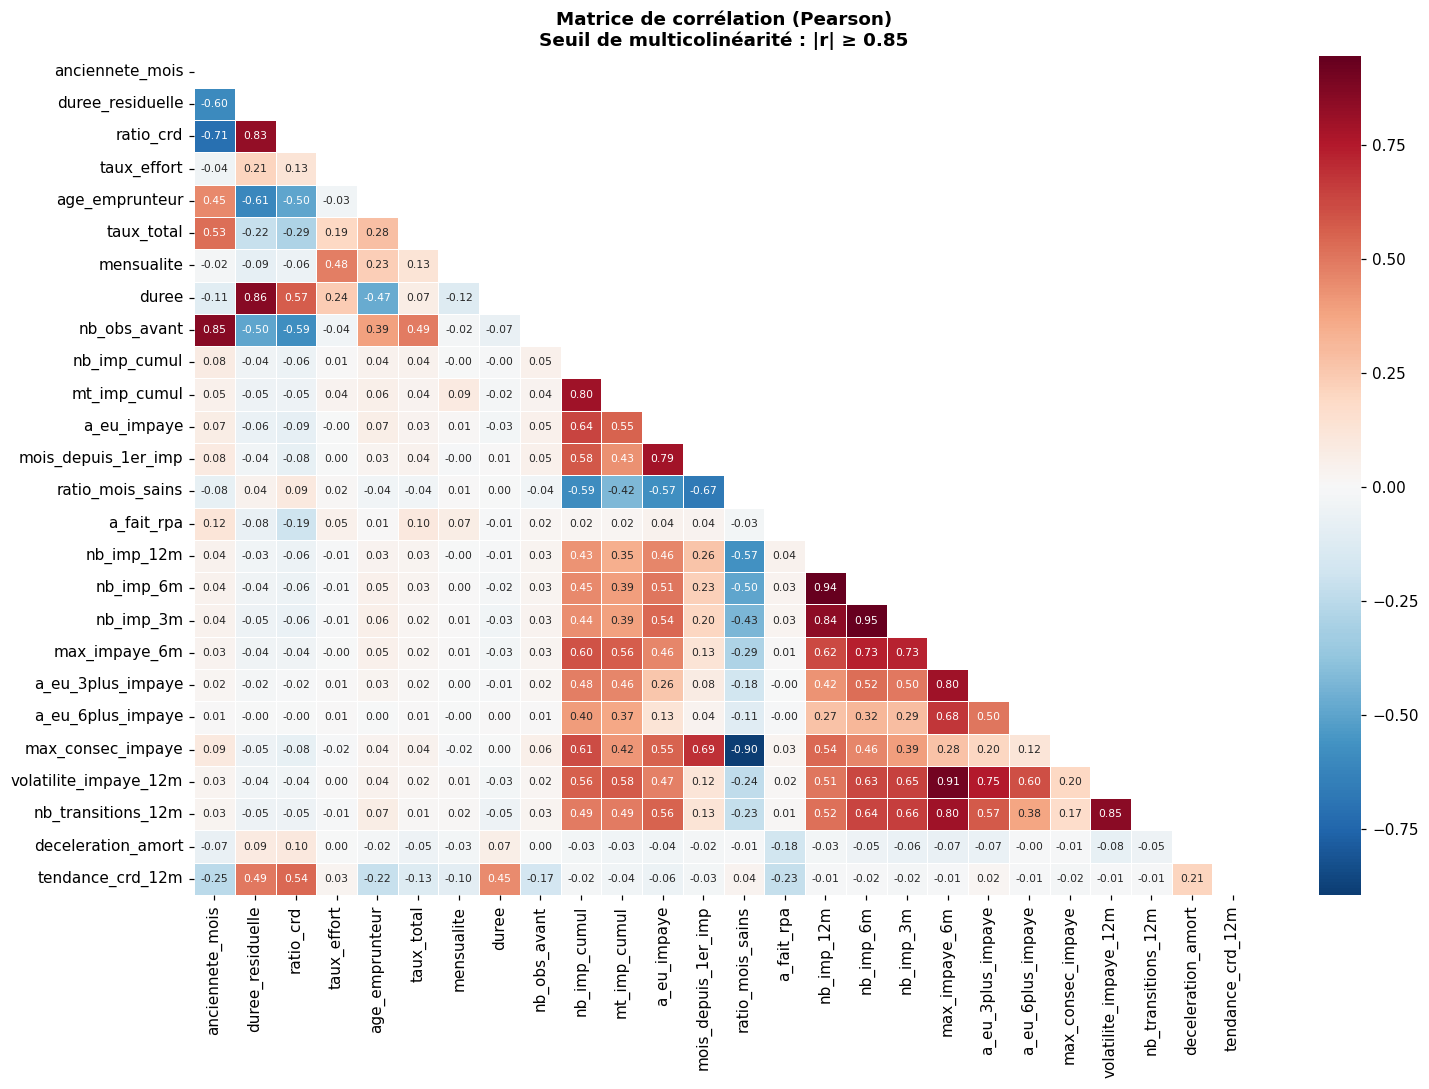

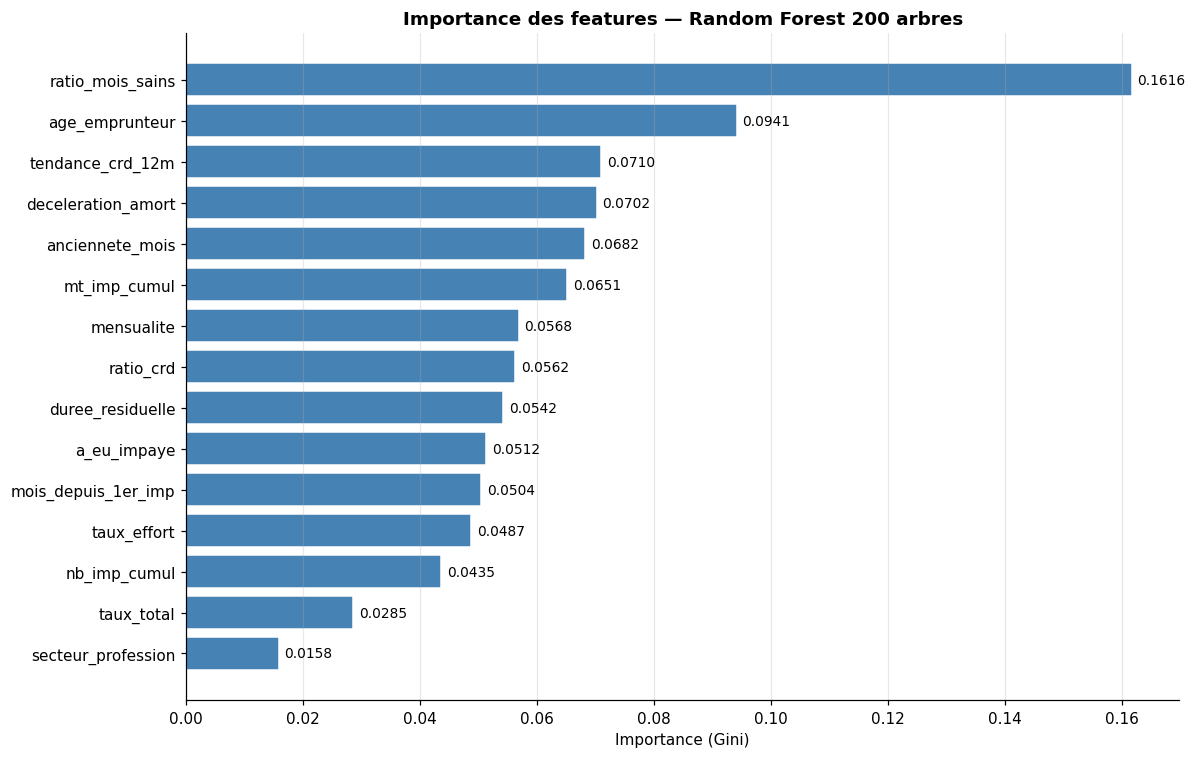

  ✔ A_matrice_correlation.png | A_feature_importance.png sauvegardés
  ✔ Checkpoint 'apres_bloc9' sauvé (5 variables) → /content/drive/MyDrive/data_PFE/checkpoint_apres_bloc9.pkl


In [ ]:
# ##############################################################################
# BLOC 9 — GRAPHIQUES EXPLORATOIRES
# ##############################################################################

fig_corr, ax_corr = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.4,
            annot_kws={"size": 7}, ax=ax_corr)
ax_corr.set_title(
    f"Matrice de corrélation (Pearson)\nSeuil de multicolinéarité : |r| ≥ {SEUIL_CORR}",
    fontweight="bold")
plt.tight_layout()
plt.savefig(DRIVE+"A_matrice_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

fig_imp, ax_imp = plt.subplots(figsize=(11, 7))
top15 = imp_df.head(15).sort_values("Importance")
bars = ax_imp.barh(top15["Variable"], top15["Importance"],
                   color="steelblue", edgecolor="white")
for bar, v in zip(bars, top15["Importance"]):
    ax_imp.text(v+0.001, bar.get_y()+bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=9)
ax_imp.set_title("Importance des features — Random Forest 200 arbres", fontweight="bold")
ax_imp.set_xlabel("Importance (Gini)"); ax_imp.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE+"A_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  ✔ A_matrice_correlation.png | A_feature_importance.png sauvegardés")
sauver_etat("apres_bloc9")

In [ ]:
# ##############################################################################
# BLOC 10 — SPLIT 60/20/20 + FONCTIONS UTILITAIRES
# ##############################################################################

def ohe_transform(df_part, ohe, features_cat):
    arr  = ohe.transform(df_part[features_cat])
    cols = ohe.get_feature_names_out(features_cat).tolist()
    return pd.DataFrame(arr, columns=cols, index=df_part.index)

def scale_transform(df_part, scaler, features_num):
    arr = scaler.transform(df_part[features_num])
    return pd.DataFrame(arr, columns=features_num, index=df_part.index)

def assemble(num_part, ohe_part):
    return pd.concat([num_part.reset_index(drop=True),
                      ohe_part.reset_index(drop=True)], axis=1).values

def preparer_tree(df_part, features_num, features_cat, medians, modes):
    df_c = df_part.copy()
    for c in features_num:  df_c[c] = df_c[c].fillna(medians[c])
    for c in features_cat:
        df_c[c] = df_c[c].fillna(modes[c])
        df_c[c] = df_c[c].astype("category").cat.codes
    return df_c[features_num+features_cat].values

def bootstrap_auc(y_true, y_proba, n_iter=2000, random_state=42):
    rng = np.random.RandomState(random_state)
    aucs = []
    n = len(y_true)
    for _ in range(n_iter):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2: continue
        aucs.append(roc_auc_score(y_true[idx], y_proba[idx]))
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Split
df_model = df[ALL_FEATURES + [TARGET, "ie_affaire"]].copy()
y_raw    = df_model[TARGET].values
idx_all  = np.arange(len(y_raw))

idx_trainval, idx_test = train_test_split(
    idx_all, test_size=SIZE_TEST, random_state=RANDOM_STATE, stratify=y_raw)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=SIZE_VAL/(1-SIZE_TEST),
    random_state=RANDOM_STATE, stratify=y_raw[idx_trainval])

df_train_base = df_model.iloc[idx_train].copy()
df_val_base   = df_model.iloc[idx_val].copy()
df_test_base  = df_model.iloc[idx_test].copy()

print("=" * 70)
print("  SPLIT 60/20/20 — Stratifié sur Y")
print("=" * 70)
print(f"\n  {'Sous-ensemble':<18} {'N':>8}  {'Y=0':>8}  {'Y=1':>6}  {'Taux CTX':>10}")
print(f"  {'─'*56}")
for label, idx_set in [("Train (60%)",idx_train),("Validation (20%)",idx_val),("Test (20%)",idx_test)]:
    y_s = y_raw[idx_set]
    print(f"  {label:<18} {len(y_s):>8,}  {(y_s==0).sum():>8,}  {(y_s==1).sum():>6}  {y_s.mean():>10.4%}")
print(f"\n  ✔ Split identique pour les {len(MODELES)} modèles × {len(SITUATIONS)} situations")

sauver_etat("apres_bloc10")

  SPLIT 60/20/20 — Stratifié sur Y

  Sous-ensemble             N       Y=0     Y=1    Taux CTX
  ────────────────────────────────────────────────────────
  Train (60%)          21,942    21,854      88     0.4011%
  Validation (20%)      7,315     7,285      30     0.4101%
  Test (20%)            7,315     7,285      30     0.4101%

  ✔ Split identique pour les 3 modèles × 3 situations
  ✔ Checkpoint 'apres_bloc10' sauvé (9 variables) → /content/drive/MyDrive/data_PFE/checkpoint_apres_bloc10.pkl


In [ ]:
# ##############################################################################
# BLOC 11 — ENTRAÎNEMENT 3 MODÈLES × 3 SITUATIONS
# ##############################################################################

print("\n" + "=" * 70)
print("  BLOC 11 — ENTRAÎNEMENT DES MODÈLES (3 × 3)")
print("=" * 70)

# ── 1. IMPUTATION (statistiques du TRAIN uniquement) ───────────────────────
for c in FEATURES_NUM:
    med = df_train_base[c].median()
    df_train_base[c] = df_train_base[c].fillna(med)
    df_val_base[c]   = df_val_base[c].fillna(med)
    df_test_base[c]  = df_test_base[c].fillna(med)

for c in FEATURES_CAT:
    mv = df_train_base[c].mode()
    mode_val = mv[0] if len(mv) > 0 else "INC"
    df_train_base[c] = df_train_base[c].fillna(mode_val)
    df_val_base[c]   = df_val_base[c].fillna(mode_val)
    df_test_base[c]  = df_test_base[c].fillna(mode_val)

# ── 2. OBJETS DE PRÉTRAITEMENT (fités sur TRAIN) ──────────────────────────
scaler = StandardScaler()
scaler.fit(df_train_base[FEATURES_NUM])

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")
if FEATURES_CAT:
    ohe.fit(df_train_base[FEATURES_CAT])

medians_tree = {c: df_train_base[c].median() for c in FEATURES_NUM}
modes_tree   = {c: (df_train_base[c].mode()[0] if df_train_base[c].notna().any() else "INC")
                for c in FEATURES_CAT}

# ── 3. CONSTRUCTION DES MATRICES ───────────────────────────────────────────
X_train_tree = preparer_tree(df_train_base, FEATURES_NUM, FEATURES_CAT, medians_tree, modes_tree)
X_val_tree   = preparer_tree(df_val_base,   FEATURES_NUM, FEATURES_CAT, medians_tree, modes_tree)
X_test_tree  = preparer_tree(df_test_base,  FEATURES_NUM, FEATURES_CAT, medians_tree, modes_tree)

if FEATURES_CAT:
    X_train_lr = assemble(scale_transform(df_train_base, scaler, FEATURES_NUM),
                          ohe_transform(df_train_base, ohe, FEATURES_CAT))
    X_val_lr   = assemble(scale_transform(df_val_base,   scaler, FEATURES_NUM),
                          ohe_transform(df_val_base,   ohe, FEATURES_CAT))
    X_test_lr  = assemble(scale_transform(df_test_base,  scaler, FEATURES_NUM),
                          ohe_transform(df_test_base,  ohe, FEATURES_CAT))
else:
    X_train_lr = scale_transform(df_train_base, scaler, FEATURES_NUM).values
    X_val_lr   = scale_transform(df_val_base,   scaler, FEATURES_NUM).values
    X_test_lr  = scale_transform(df_test_base,  scaler, FEATURES_NUM).values

y_train = df_train_base[TARGET].values
y_val   = df_val_base[TARGET].values
y_test  = df_test_base[TARGET].values

print(f"  Tree : Train={X_train_tree.shape} | Val={X_val_tree.shape} | Test={X_test_tree.shape}")
print(f"  LR   : Train={X_train_lr.shape} | Val={X_val_lr.shape} | Test={X_test_lr.shape}")
print(f"  Y=1  : Train={y_train.sum():,} | Val={y_val.sum():,} | Test={y_test.sum():,}")

# ── 4. BOUCLE D'ENTRAÎNEMENT / ÉVALUATION ─────────────────────────────────
resultats_all = {}

for nom_situation, cfg in SITUATIONS.items():
    print(f"\n  {'─'*60}")
    print(f"  SITUATION {cfg['num']} — {nom_situation}")
    print(f"  {cfg['description']}")
    print(f"  {'─'*60}")

    for nom_modele in MODELES:
        cle = f"{nom_situation}_{nom_modele}"
        print(f"\n    → {nom_modele}")

        # ---- Entraînement selon le modèle ----
        if nom_modele == "RegLog":
            sm = SMOTE(sampling_strategy=cfg["smote_ratio"], random_state=RANDOM_STATE)
            X_tr_sm, y_tr_sm = sm.fit_resample(X_train_lr, y_train)

            m = LogisticRegression(C=cfg["C_logreg"], class_weight="balanced",
                                   max_iter=2000, random_state=RANDOM_STATE)
            m.fit(X_tr_sm, y_tr_sm)

            p_val  = m.predict_proba(X_val_lr)[:, 1]
            p_test = m.predict_proba(X_test_lr)[:, 1]

            feat_names_lr = list(FEATURES_NUM)
            if FEATURES_CAT:
                feat_names_lr += list(ohe.get_feature_names_out(FEATURES_CAT))
            coefs = m.coef_[0]
            df_coef = pd.DataFrame({
                "Variable": feat_names_lr,
                "Coefficient": coefs,
                "Odds_Ratio": np.exp(coefs)
            }).sort_values("Coefficient", ascending=False)

        elif nom_modele == "RF":
            m = RandomForestClassifier(
                n_estimators=cfg["rf_estimators"],
                max_depth=cfg["rf_depth"],
                class_weight="balanced",
                random_state=RANDOM_STATE, n_jobs=-1)
            m.fit(X_train_tree, y_train)

            p_val  = m.predict_proba(X_val_tree)[:, 1]
            p_test = m.predict_proba(X_test_tree)[:, 1]

            df_coef = pd.DataFrame({
                "Variable": FEATURES_NUM + FEATURES_CAT,
                "Coefficient": m.feature_importances_
            }).sort_values("Coefficient", ascending=False)

        else:  # XGBoost
            spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
            m = XGBClassifier(
                n_estimators=cfg["xgb_estimators"],
                max_depth=cfg["xgb_depth"],
                learning_rate=cfg["xgb_lr"],
                scale_pos_weight=spw,
                random_state=RANDOM_STATE, n_jobs=-1,
                eval_metric="logloss")
            m.fit(X_train_tree, y_train, verbose=False)

            p_val  = m.predict_proba(X_val_tree)[:, 1]
            p_test = m.predict_proba(X_test_tree)[:, 1]

            df_coef = pd.DataFrame({
                "Variable": FEATURES_NUM + FEATURES_CAT,
                "Coefficient": m.feature_importances_
            }).sort_values("Coefficient", ascending=False)

        # ---- Calibration isotonique (sur validation) ----
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(p_val, y_val)
        p_val_cal  = iso.transform(p_val)
        p_test_cal = iso.transform(p_test)

        # ---- Optimisation du seuil (F3 sur validation) ----
        seuils = np.linspace(0.01, 0.99, 200)
        best_f3, best_s = 0, 0.5
        fb_scores = []
        for s in seuils:
            y_pred_v = (p_val_cal >= s).astype(int)
            f3 = fbeta_score(y_val, y_pred_v, beta=3, zero_division=0)
            fb_scores.append(f3)
            if f3 > best_f3:
                best_f3, best_s = f3, s

        # ---- Évaluation TEST ----
        y_pred_test = (p_test_cal >= best_s).astype(int)
        cm = confusion_matrix(y_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()

        rappel    = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f2_test   = fbeta_score(y_test, y_pred_test, beta=2, zero_division=0)
        f3_test   = fbeta_score(y_test, y_pred_test, beta=3, zero_division=0)
        auc_test  = roc_auc_score(y_test, p_test_cal)
        brier_test = brier_score_loss(y_test, p_test_cal)
        auc_lo, auc_hi = bootstrap_auc(y_test, p_test_cal)

        # ---- Sauvegarde ----
        tag = f"sit{cfg['num']}_{nom_situation}_{nom_modele}".replace(" ", "_").lower()
        joblib.dump(m, DRIVE + f"modele_{tag}.pkl")

        # ---- Stockage dans resultats_all ----
        resultats_all[cle] = {
            "situation": nom_situation,
            "modele": nom_modele,
            "num_sit": cfg["num"],
            "couleur": cfg["couleur"],
            "tag": tag,
            "auc_roc": auc_test,
            "auc_low": auc_lo,
            "auc_high": auc_hi,
            "brier": brier_test,
            "f2": f2_test,
            "f3": f3_test,
            "rappel": rappel,
            "precision": precision,
            "seuil": best_s,
            "fb_score_opt": best_f3,
            "seuils_cands": seuils,
            "fb_scores": fb_scores,
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "cm_test": cm,
            "y_test": y_test,
            "y_test_proba": p_test_cal,
            "y_val": y_val,
            "y_val_proba": p_val_cal,
            "coef_df": df_coef,
            "PD_test": float(p_test_cal.mean()),
            "PD_sans_smote": float(p_test_cal.mean()),
            "PD_observee": float(y_test.mean()),
            "ecart_pct": float((p_test_cal.mean() - y_test.mean()) / max(y_test.mean(), 1e-6) * 100),
        }

        print(f"      AUC={auc_test:.4f} [{auc_lo:.3f};{auc_hi:.3f}] | "
              f"F3={f3_test:.4f} | Rec={rappel:.3f} | Préc={precision:.3f} | "
              f"FP={fp} FN={fn} | Seuil={best_s:.3f}")

print(f"\n  {'='*60}")
print(f"  ✔ BLOC 11 terminé — {len(resultats_all)} combinaisons entraînées")
print(f"  {'='*60}")

sauver_etat("apres_bloc11")


  BLOC 11 — ENTRAÎNEMENT DES MODÈLES (3 × 3)
  Tree : Train=(21942, 23) | Val=(7315, 23) | Test=(7315, 23)
  LR   : Train=(21942, 27) | Val=(7315, 27) | Test=(7315, 27)
  Y=1  : Train=88 | Val=30 | Test=30

  ────────────────────────────────────────────────────────────
  SITUATION 1 — Conservative
  Forte régularisation — modèle stable, moins de sur-apprentissage
  ────────────────────────────────────────────────────────────

    → RegLog
      AUC=0.8673 [0.773;0.946] | F3=0.4872 | Rec=0.633 | Préc=0.158 | FP=101 FN=11 | Seuil=0.020

    → RF
      AUC=0.8944 [0.817;0.956] | F3=0.4071 | Rec=0.533 | Préc=0.130 | FP=107 FN=14 | Seuil=0.020

    → XGBoost
      AUC=0.8658 [0.779;0.938] | F3=0.4607 | Rec=0.567 | Préc=0.172 | FP=82 FN=13 | Seuil=0.030

  ────────────────────────────────────────────────────────────
  SITUATION 2 — Optimisée
  Régularisation modérée — équilibre biais/variance
  ────────────────────────────────────────────────────────────

    → RegLog
      AUC=0.8654 [0.76

In [ ]:
# ##############################################################################
# BLOC 12 V9 — LSTM ALLÉGÉ (rapide, stable, moins de FP)
# ##############################################################################

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.isotonic import IsotonicRegression
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("=" * 60)
print("  BLOC 12 V9 — LSTM ALLÉGÉ (rapide)")
print("=" * 60)

# ─── PARAMÈTRES COMPACTS ───────────────────────────────────────────────
T_SEQ = 24
CACHE_SEQ = DRIVE + "_cache_X_lstm_v9.npz"

SITUATIONS_LSTM = {
    "Conservative": {"units": 32, "dropout": 0.3, "cw_factor": 1.0,
                     "batch_size": 512, "lr": 0.002, "couleur": "steelblue", "num": 1},
    "Optimisée":    {"units": 48, "dropout": 0.25, "cw_factor": 1.5,
                     "batch_size": 512, "lr": 0.001, "couleur": "seagreen", "num": 2},
    "Stressée":     {"units": 32, "dropout": 0.2, "cw_factor": 2.0,
                     "batch_size": 512, "lr": 0.001, "couleur": "tomato", "num": 3},
}

# ─── ARCHITECTURE SIMPLE ───────────────────────────────────────────────
def build_lstm_simple(cfg, t_seq, n_seq_feat, n_stat_feat):
    inp_seq = keras.Input(shape=(t_seq, n_seq_feat), name="input_seq")
    x = layers.Masking(mask_value=0.0)(inp_seq)
    x = layers.LSTM(cfg["units"], return_sequences=False, dropout=cfg["dropout"])(x)
    x = layers.Dense(cfg["units"] // 2, activation="relu")(x)
    x = layers.Dropout(cfg["dropout"])(x)

    inp_stat = keras.Input(shape=(n_stat_feat,), name="input_stat")
    s = layers.Dense(16, activation="relu")(inp_stat)

    merged = layers.Concatenate()([x, s])
    m = layers.Dense(16, activation="relu")(merged)
    output = layers.Dense(1, activation="sigmoid", name="output")(m)
    return Model(inputs=[inp_seq, inp_stat], outputs=output, name="LSTM_V9_simple")

# ─── SÉQUENCES (cache ou construction rapide) ─────────────────────────
if os.path.exists(CACHE_SEQ):
    data_cache = np.load(CACHE_SEQ)
    X_lstm_seq_raw = data_cache["X_seq"]
    FEATURES_SEQ_DISPO = list(data_cache["features_seq"])
else:
    FEATURES_SEQ = ["statut_num", "impaye_nombre", "crd", "montant_rpa"]
    df_avant_lstm = df_avant.copy()
    df_avant_lstm["statut_num"] = df_avant_lstm["statut_comptable"].astype(str).str.upper().str.strip().map(
        lambda s: 0.0 if s == "SNA" else (1.0 if s == "CTX" else 0.5))

    FEATURES_SEQ_DISPO = [c for c in FEATURES_SEQ if c in df_avant_lstm.columns]
    n_features_seq = len(FEATURES_SEQ_DISPO)

    for col in FEATURES_SEQ_DISPO:
        df_avant_lstm[col] = df_avant_lstm[col].fillna(0)

    ids_ordered = df_model["ie_affaire"].values
    n_credits = len(ids_ordered)
    X_lstm_seq_raw = np.zeros((n_credits, T_SEQ, n_features_seq), dtype=np.float32)
    grouped_lstm = df_avant_lstm.groupby("ie_affaire")

    for i, ie in enumerate(ids_ordered):
        try:
            grp = grouped_lstm.get_group(ie)[FEATURES_SEQ_DISPO].values
            L = min(len(grp), T_SEQ)
            X_lstm_seq_raw[i, T_SEQ - L:] = grp[-L:]
        except KeyError:
            pass

    np.savez(CACHE_SEQ, X_seq=X_lstm_seq_raw, features_seq=np.array(FEATURES_SEQ_DISPO))

n_features_seq = X_lstm_seq_raw.shape[2]
print(f"  Séquences : {X_lstm_seq_raw.shape}")

# ─── STATIQUES + SPLIT ─────────────────────────────────────────────────
FEATURES_STAT_LSTM = [c for c in FEATURES_NUM if c in df_model.columns][:10]
n_features_stat = len(FEATURES_STAT_LSTM)
X_lstm_stat_raw = df_model[FEATURES_STAT_LSTM].fillna(df_model[FEATURES_STAT_LSTM].median()).values.astype(np.float32)
y_lstm = df_model[TARGET].values

X_seq_train, X_seq_val, X_seq_test = X_lstm_seq_raw[idx_train], X_lstm_seq_raw[idx_val], X_lstm_seq_raw[idx_test]
X_stat_train, X_stat_val, X_stat_test = X_lstm_stat_raw[idx_train], X_lstm_stat_raw[idx_val], X_lstm_stat_raw[idx_test]
y_train_l, y_val_l, y_test_l = y_lstm[idx_train], y_lstm[idx_val], y_lstm[idx_test]

# Normalisation
for arr in [X_stat_train, X_stat_val, X_stat_test]:
    mins, maxs = X_stat_train.min(axis=0), X_stat_train.max(axis=0)
    denom = np.where(maxs - mins > 1e-8, maxs - mins, 1.0)
    arr[:] = (arr - mins) / denom

n_pos_lstm, n_neg_lstm = (y_train_l == 1).sum(), (y_train_l == 0).sum()
ratio_base = n_neg_lstm / max(n_pos_lstm, 1)
print(f"  Train={len(y_train_l):,} | Val={len(y_val_l):,} | Test={len(y_test_l):,} | Ratio={ratio_base:.0f}:1")

# ─── ENTRAÎNEMENT × 3 SITUATIONS ─────────────────────────────────────
resultats_lstm_v4 = {}

for nom_situation, cfg_lstm in SITUATIONS_LSTM.items():
    tag = f"sit{cfg_lstm['num']}_{nom_situation}_lstm".replace(" ","_").lower()
    cw = {0: 1.0, 1: ratio_base * cfg_lstm["cw_factor"]}

    tf.keras.backend.clear_session()
    model_lstm = build_lstm_simple(cfg_lstm, T_SEQ, n_features_seq, n_features_stat)
    model_lstm.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg_lstm["lr"]),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")])

    history = model_lstm.fit(
        x=[X_seq_train, X_stat_train], y=y_train_l,
        validation_data=([X_seq_val, X_stat_val], y_val_l),
        epochs=30,
        batch_size=cfg_lstm["batch_size"],
        class_weight=cw,
        callbacks=[
            EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6, verbose=0)],
        verbose=0)

    p_val = model_lstm.predict([X_seq_val, X_stat_val], verbose=0).ravel()
    p_test = model_lstm.predict([X_seq_test, X_stat_test], verbose=0).ravel()

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_val, y_val_l)
    p_val_cal = iso.transform(p_val)
    p_test_cal = iso.transform(p_test)

    auc_l = roc_auc_score(y_test_l, p_test_cal)
    brier_l = brier_score_loss(y_test_l, p_test_cal)

    seuils = np.linspace(0.01, 0.99, 200)
    best_f1, best_s = 0, 0.5
    for s in seuils:
        y_pred_v = (p_val_cal >= s).astype(int)
        f1 = fbeta_score(y_val_l, y_pred_v, beta=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_s = f1, s

    y_pred_test = (p_test_cal >= best_s).astype(int)
    cm = confusion_matrix(y_test_l, y_pred_test)
    tn, fp, fn, tp = cm.ravel()
    rappel = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f2_l = fbeta_score(y_test_l, y_pred_test, beta=2, zero_division=0)
    f3_l = fbeta_score(y_test_l, y_pred_test, beta=3, zero_division=0)

    model_lstm.save(DRIVE + f"modele_{tag}.keras")

    resultats_lstm_v4[f"{nom_situation}_LSTM"] = {
        "situation": nom_situation, "modele": "LSTM", "num_sit": cfg_lstm["num"],
        "couleur": cfg_lstm["couleur"], "tag": tag,
        "auc_roc": auc_l, "auc_low": auc_l, "auc_high": auc_l,
        "brier": brier_l, "f2": f2_l, "f3": f3_l,
        "rappel": rappel, "precision": precision,
        "seuil": best_s, "fb_score_opt": best_f1,
        "seuils_cands": seuils, "fb_scores": [0]*len(seuils),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "cm_test": cm,
        "y_test": y_test_l, "y_test_proba": p_test_cal,
        "y_val": y_val_l, "y_val_proba": p_val_cal,
        "coef_df": pd.DataFrame(),
        "PD_test": p_test_cal.mean(),
        "PD_sans_smote": p_test_cal.mean(),
        "PD_observee": y_test_l.mean(),
        "ecart_pct": (p_test_cal.mean() - y_test_l.mean()) / max(y_test_l.mean(), 1e-6) * 100,
    }

    print(f"  {nom_situation:<13} | AUC={auc_l:.4f} | F1={best_f1:.4f} | "
          f"Rec={rappel:.3f} Pré={precision:.3f} | FP={fp} FN={fn} | Seuil={best_s:.3f}")

# ─── INTÉGRATION DANS resultats_all ──────────────────────────────────
print(f"\n  Intégration des résultats LSTM dans resultats_all...")
for cle, res in resultats_lstm_v4.items():
    resultats_all[cle] = res

print(f"\n  ✔ resultats_all : {len(resultats_all)} combinaisons")
print("  BLOC 12 V9 terminé")
sauver_etat("apres_bloc12")

  BLOC 12 V9 — LSTM ALLÉGÉ (rapide)
  Séquences : (36572, 24, 4)
  Train=21,942 | Val=7,315 | Test=7,315 | Ratio=248:1
  Conservative  | AUC=0.7531 | F1=0.1163 | Rec=0.533 Pré=0.075 | FP=197 FN=14 | Seuil=0.010
  Optimisée     | AUC=0.6632 | F1=0.2609 | Rec=0.333 Pré=0.167 | FP=50 FN=20 | Seuil=0.010
  Stressée      | AUC=0.5000 | F1=0.0000 | Rec=0.000 Pré=0.000 | FP=0 FN=30 | Seuil=0.500

  Intégration des résultats LSTM dans resultats_all...

  ✔ resultats_all : 12 combinaisons
  BLOC 12 V9 terminé
  ✔ Checkpoint 'apres_bloc12' sauvé (10 variables) → /content/drive/MyDrive/data_PFE/checkpoint_apres_bloc12.pkl


In [ ]:
# ##############################################################################
# BLOC 13 — COEFFICIENTS, IMPORTANCE ET INTERPRÉTATION ÉCONOMIQUE
# ##############################################################################

if 'SITUATIONS' not in dir():
    SITUATIONS = {
        "Conservative": {"couleur": "steelblue", "num": 1},
        "Optimisée":    {"couleur": "seagreen",  "num": 2},
        "Stressée":     {"couleur": "tomato",    "num": 3},
    }
    print("  ⚠ SITUATIONS redéfini (récupération après reset)")

print("=" * 70)
print("  BLOC 13 — COEFFICIENTS ET IMPORTANCE DES VARIABLES")
print("=" * 70)

# PARTIE 1 — RÉGRESSION LOGISTIQUE
print("\n" + "=" * 70)
print("  PARTIE 1 — RÉGRESSION LOGISTIQUE")
print("=" * 70)

for nom_situation, cfg in SITUATIONS.items():
    cle    = f"{nom_situation}_RegLog"
    if cle not in resultats_all:
        print(f"  ⚠ {cle} non trouvé dans resultats_all")
        continue
    r      = resultats_all[cle]
    df_cof = r["coef_df"].copy()

    print(f"\n  Situation {cfg['num']} — {nom_situation}")
    print(f"  AUC={r['auc_roc']:.4f}  Rappel={r['rappel']:.4f}  "
          f"FP={r['fp']}  FN={r['fn']}  PD={r['PD_test']:.4%}")

    print(f"\n  {'Variable':<35} {'Coef':>10} {'OR':>10} Sens")
    print(f"  {'─'*70}")
    for _, row in df_cof.iterrows():
        coef = row["Coefficient"]
        or_  = row["Odds_Ratio"]
        var  = row["Variable"]
        sens = "↑ RISQUE" if coef > 0 else "↓ RISQUE"
        print(f"  {var:<35} {coef:>10.4f} {or_:>10.4f} {sens}")

    augmentent = df_cof[df_cof["Coefficient"] > 0].sort_values("Coefficient", ascending=False)
    reduisent  = df_cof[df_cof["Coefficient"] < 0].sort_values("Coefficient", ascending=True)

    print(f"\n  🔴 TOP 5 VARIABLES QUI AUGMENTENT LE RISQUE :")
    for _, row in augmentent.head(5).iterrows():
        print(f"  {row['Variable']:<35} OR={row['Odds_Ratio']:.4f}")

    print(f"\n  🟢 TOP 5 VARIABLES QUI RÉDUISENT LE RISQUE :")
    for _, row in reduisent.head(5).iterrows():
        print(f"  {row['Variable']:<35} OR={row['Odds_Ratio']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f"Régression Logistique — Situation {cfg['num']} {nom_situation}", fontweight="bold")

    df_plot   = df_cof.sort_values("Coefficient")
    colors    = ["#e74c3c" if v > 0 else "#2ecc71" for v in df_plot["Coefficient"]]
    bars = axes[0].barh(df_plot["Variable"], df_plot["Coefficient"], color=colors)
    axes[0].axvline(0, color="black", lw=1, ls="--")
    axes[0].set_title("Coefficients logistiques")

    df_or     = df_cof.sort_values("Odds_Ratio", ascending=False).head(15)
    colors_or = ["#e74c3c" if v > 1 else "#2ecc71" for v in df_or["Odds_Ratio"]]
    bars2 = axes[1].barh(df_or["Variable"].iloc[::-1], df_or["Odds_Ratio"].iloc[::-1], color=colors_or[::-1])
    axes[1].axvline(1, color="black", lw=1.5, ls="--")
    axes[1].set_title("Odds Ratio (Top 15)")

    plt.tight_layout()
    fname = DRIVE + f"B_RegLog_Coef_Sit{cfg['num']}_{nom_situation}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✔ {fname}")

# PARTIE 2 — RANDOM FOREST
print("\n" + "=" * 70)
print("  PARTIE 2 — RANDOM FOREST")
print("=" * 70)

for nom_situation, cfg in SITUATIONS.items():
    cle    = f"{nom_situation}_RF"
    if cle not in resultats_all:
        continue
    r      = resultats_all[cle]
    df_cof = r["coef_df"].copy().sort_values("Coefficient", ascending=False)

    print(f"\n  Situation {cfg['num']} — {nom_situation}")
    print(f"  AUC={r['auc_roc']:.4f}  Rappel={r['rappel']:.4f}  FP={r['fp']}  FN={r['fn']}")

    print(f"\n  {'Variable':<35} {'Importance':>12}")
    for _, row in df_cof.head(10).iterrows():
        print(f"  {row['Variable']:<35} {row['Coefficient']:>12.4f}")

    fig, ax = plt.subplots(figsize=(12, 8))
    top15     = df_cof.head(15).sort_values("Coefficient")
    colors_rf = plt.cm.Blues(np.linspace(0.3, 0.9, len(top15)))
    bars = ax.barh(top15["Variable"], top15["Coefficient"], color=colors_rf)
    ax.set_title("Top 15 variables — Importance Gini")
    plt.tight_layout()
    fname = DRIVE + f"B_RF_Importance_Sit{cfg['num']}_{nom_situation}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✔ {fname}")

# PARTIE 3 — XGBOOST
print("\n" + "=" * 70)
print("  PARTIE 3 — XGBOOST")
print("=" * 70)

for nom_situation, cfg in SITUATIONS.items():
    cle    = f"{nom_situation}_XGBoost"
    if cle not in resultats_all:
        continue
    r      = resultats_all[cle]
    df_cof = r["coef_df"].copy().sort_values("Coefficient", ascending=False)

    print(f"\n  Situation {cfg['num']} — {nom_situation}")
    print(f"  AUC={r['auc_roc']:.4f}  Rappel={r['rappel']:.4f}  FP={r['fp']}  FN={r['fn']}")

    fig, ax = plt.subplots(figsize=(12, 8))
    top15      = df_cof.head(15).sort_values("Coefficient")
    colors_xgb = plt.cm.Oranges(np.linspace(0.3, 0.9, len(top15)))
    bars = ax.barh(top15["Variable"], top15["Coefficient"], color=colors_xgb)
    ax.set_title("Top 15 variables — Importance XGBoost")
    plt.tight_layout()
    fname = DRIVE + f"B_XGBoost_Importance_Sit{cfg['num']}_{nom_situation}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✔ {fname}")

print(f"\n  ✔ BLOC 13 terminé")

  BLOC 13 — COEFFICIENTS ET IMPORTANCE DES VARIABLES

  PARTIE 1 — RÉGRESSION LOGISTIQUE

  Situation 1 — Conservative
  AUC=0.8673  Rappel=0.6333  FP=101  FN=11  PD=0.3763%

  Variable                                  Coef         OR Sens
  ──────────────────────────────────────────────────────────────────────
  age_emprunteur                          0.9660     2.6275 ↑ RISQUE
  qualite_MR                              0.6100     1.8405 ↑ RISQUE
  ratio_crd                               0.5999     1.8220 ↑ RISQUE
  a_eu_impaye                             0.5714     1.7707 ↑ RISQUE
  situation_famille_C                     0.4540     1.5745 ↑ RISQUE
  objet_financement_ACQU                  0.3757     1.4561 ↑ RISQUE
  secteur_profession_SECURITE_DEFENSE     0.3501     1.4192 ↑ RISQUE
  a_eu_3plus_impaye                       0.2118     1.2359 ↑ RISQUE
  anciennete_mois                         0.1423     1.1529 ↑ RISQUE
  tendance_crd_12m                        0.1347     1.1442 ↑ RISQ

In [ ]:
# ##############################################################################
# BLOC 14 — COURBE F3-SCORE vs SEUIL
# ##############################################################################

MODELES_COMPLETS = ["RegLog", "RF", "XGBoost", "LSTM"]

for nom_modele in MODELES_COMPLETS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"F3-score vs Seuil — {nom_modele}", fontweight="bold")

    for idx_s, (nom_situation, cfg) in enumerate(SITUATIONS.items()):
        cle = f"{nom_situation}_{nom_modele}"
        if cle not in resultats_all:
            axes[idx_s].set_visible(False)
            continue
        r  = resultats_all[cle]
        ax = axes[idx_s]
        ax.plot(r["seuils_cands"], r["fb_scores"], color=cfg["couleur"], lw=2)
        ax.axvline(r["seuil"], color="red", ls="--", lw=2, label=f"Seuil opt={r['seuil']:.4f}")
        ax.axvline(0.5, color="gray", ls=":", lw=1.5, label="Seuil=0.5")
        ax.set_xlabel("Seuil"); ax.set_ylabel("F3-score")
        ax.set_title(f"Sit.{cfg['num']} — {nom_situation}")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    fname = DRIVE + f"B_Fbeta_{nom_modele}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✔ {fname}")

print(f"\n  ✔ BLOC 14 terminé")

  ✔ /content/drive/MyDrive/data_PFE/B_Fbeta_RegLog.png
  ✔ /content/drive/MyDrive/data_PFE/B_Fbeta_RF.png
  ✔ /content/drive/MyDrive/data_PFE/B_Fbeta_XGBoost.png
  ✔ /content/drive/MyDrive/data_PFE/B_Fbeta_LSTM.png

  ✔ BLOC 14 terminé


In [ ]:
# ##############################################################################
# BLOC 15 — MATRICES EN % + DISTRIBUTION DES PD
# ##############################################################################

print('=' * 70)
print('  BLOC 15 — MATRICES (%) + DISTRIBUTION DES PD')
print('=' * 70)

for nom_situation, cfg in SITUATIONS.items():
    fig, axes = plt.subplots(2, 4, figsize=(28, 12))
    fig.suptitle(f"Matrices (%) et Distributions PD — Situation {cfg['num']} — {nom_situation}", fontweight='bold')

    for idx_m, nom_modele in enumerate(MODELES_COMPLETS):
        cle = f"{nom_situation}_{nom_modele}"
        if cle not in resultats_all:
            axes[0, idx_m].set_visible(False)
            axes[1, idx_m].set_visible(False)
            continue

        r  = resultats_all[cle]
        cm = r['cm_test']
        p_test = r['y_test_proba']
        y_test_cm = r['y_test']
        seuil = r['seuil']

        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        annot_labels = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
        sns.heatmap(cm_pct, annot=annot_labels, fmt='', cmap='Blues',
                    xticklabels=['Prédit SAIN', 'Prédit CTX'],
                    yticklabels=['Réel SAIN', 'Réel CTX'],
                    ax=axes[0, idx_m], linewidths=2, linecolor='white')
        axes[0, idx_m].set_title(f"{nom_modele} - Matrice (%)", fontweight='bold')

        p_sain = p_test[y_test_cm == 0]
        p_ctx  = p_test[y_test_cm == 1]
        data_plot = [p_sain] + ([p_ctx] if len(p_ctx) > 0 else [])
        labels_plot = ['Sain'] + (['CTX'] if len(p_ctx) > 0 else [])
        axes[1, idx_m].boxplot(data_plot, labels=labels_plot, patch_artist=True, showmeans=True)
        axes[1, idx_m].axhline(y=seuil, color='red', linestyle='--', label=f'Seuil={seuil:.3f}')
        axes[1, idx_m].set_yscale('log')
        axes[1, idx_m].set_title(f"{nom_modele} - Distribution PD", fontweight='bold')
        axes[1, idx_m].legend(fontsize=8)

    plt.tight_layout()
    fname = os.path.join(DRIVE, f"C_ConfusionMatrix_Sit{cfg['num']}_{nom_situation}.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close()

print('\n✔ BLOC 15 terminé')

  BLOC 15 — MATRICES (%) + DISTRIBUTION DES PD

✔ BLOC 15 terminé


In [ ]:
# ##############################################################################
# BLOC 16-17 — COMPARAISON FINALE + CHAMPIONS
# ##############################################################################

print("=" * 70)
print("  BLOC 17 — TABLEAU COMPARATIF (12+ combinaisons)")
print("=" * 70)

# Calcul F3 pour toutes les combinaisons
for cle, r in resultats_all.items():
    if "f3" not in r:
        r["f3"] = fbeta_score(r["y_test"], (r["y_test_proba"] >= r["seuil"]).astype(int), beta=3, zero_division=0)

print(f"\n  {'Modèle':<12} {'Situation':<16} {'AUC':>8} {'IC95%':>16} "
      f"{'F3':>8} {'Brier':>10} {'Rappel':>8} {'FP':>5} {'FN':>5} {'PD modèle':>10}")
print(f"  {'─'*105}")

for nom_modele in MODELES_COMPLETS:
    for nom_situation in SITUATIONS:
        cle = f"{nom_situation}_{nom_modele}"
        if cle not in resultats_all:
            continue
        r  = resultats_all[cle]
        ic = f"[{r.get('auc_low', r['auc_roc']):.3f};{r.get('auc_high', r['auc_roc']):.3f}]"
        print(f"  {nom_modele:<12} {nom_situation:<16} "
              f"{r['auc_roc']:>8.4f} {ic:>16} "
              f"{r['f3']:>8.4f} {r['brier']:>10.6f} "
              f"{r['rappel']:>8.4f} {r['fp']:>5} {r['fn']:>5} "
              f"{r['PD_test']:>10.4%}")
    print(f"  {'─'*105}")

# ─── CHAMPIONS PAR MODÈLE ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("  CHAMPION PAR MODÈLE")
print("=" * 70)

champions       = {}
champions_finaux = {}

for nom_modele in MODELES_COMPLETS:
    r_list = []
    for nom_sit in SITUATIONS:
        cle = f"{nom_sit}_{nom_modele}"
        if cle in resultats_all:
            r_list.append(resultats_all[cle])

    if not r_list:
        print(f"\n  ⚠ {nom_modele} : aucune situation disponible, ignoré.")
        continue

    n = len(r_list)
    scores = []
    for i in range(n):
        sc = (sorted(range(n), key=lambda x: -r_list[x]["auc_roc"]).index(i) * 0.45
            + sorted(range(n), key=lambda x: -r_list[x]["f3"]).index(i)     * 0.30
            + sorted(range(n), key=lambda x: -r_list[x]["rappel"]).index(i) * 0.15
            + sorted(range(n), key=lambda x:  r_list[x]["brier"]).index(i)  * 0.10)
        scores.append(sc)

    idx_champ              = int(np.argmin(scores))
    champion               = r_list[idx_champ]
    champions[nom_modele]  = champion
    champions_finaux[nom_modele] = champion

    print(f"\n  {nom_modele} :")
    print(f"  {'─'*65}")
    for i, r in enumerate(r_list):
        flag = "  ← CHAMPION" if i == idx_champ else ""
        print(f"    Sit.{r['num_sit']} {r['situation']:<16} "
              f"AUC={r['auc_roc']:.4f}  F3={r['f3']:.4f}  "
              f"Rappel={r['rappel']:.4f}  FP={r['fp']}  "
              f"Score={scores[i]:.2f}{flag}")

print(f"\n  ★ champions_finaux créé : {len(champions_finaux)} modèles")

# Récapitulatif
print("\n" + "=" * 70)
print(f"  RÉCAPITULATIF — {len(champions_finaux)} CHAMPIONS")
print("=" * 70)
print(f"\n  {'Modèle':<12} {'Situation':<16} {'AUC':>8} {'F3':>8} "
      f"{'Rappel':>8} {'FP':>5} {'PD modèle':>10}")
print(f"  {'─'*72}")
for nom_modele, r in champions_finaux.items():
    print(f"  {nom_modele:<12} {r['situation']:<16} "
          f"{r['auc_roc']:>8.4f} {r['f3']:>8.4f} "
          f"{r['rappel']:>8.4f} {r['fp']:>5} "
          f"{r['PD_test']:>10.4%}")

sauver_etat("apres_bloc17")
print(f"\n  ✔ BLOC 17 terminé")

  BLOC 17 — TABLEAU COMPARATIF (12+ combinaisons)

  Modèle       Situation             AUC            IC95%       F3      Brier   Rappel    FP    FN  PD modèle
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────
  RegLog       Conservative       0.8673    [0.773;0.946]   0.4872   0.003207   0.6333   101    11    0.3763%
  RegLog       Optimisée          0.8654    [0.769;0.946]   0.5128   0.003243   0.6000    63    12    0.3753%
  RegLog       Stressée           0.8482    [0.744;0.937]   0.5215   0.003248   0.5667    39    13    0.3646%
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────
  RF           Conservative       0.8944    [0.817;0.956]   0.4071   0.003512   0.5333   107    14    0.5059%
  RF           Optimisée          0.8922    [0.812;0.956]   0.4023   0.003492   0.4667    64    16    0.4959%
  RF           Stressée           0.8848    [0.806;0.947]   0.3966   0.00

In [ ]:
# ##############################################################################
# BLOC 18 V4 — ENSEMBLE 4 MODÈLES + DÉCISION FINALE
# ##############################################################################

import itertools
from scipy.stats import rankdata

print("=" * 70)
print("  BLOC 18 V4 — ENSEMBLE 4 MODÈLES (cible : 70-80% CTX, FP contrôlés)")
print("=" * 70)

# Vérification
if not champions_finaux:
    raise RuntimeError("champions_finaux est vide. Re-exécute le BLOC 17.")

print(f"\n  Champions identifiés ({len(champions_finaux)} modèles) :")
for nom_m, r in champions_finaux.items():
    print(f"  {nom_m:<12} → {r['situation']:<16} "
          f"AUC={r['auc_roc']:.4f}  F2={r.get('f2', r.get('f3', 0)):.4f}  "
          f"Rappel={r['rappel']:.4f}  FP={r['fp']}  PD={r['PD_test']:.3%}")

FP_BASELINE = min(r["fp"] for r in champions_finaux.values())
PLAFOND_FP_ENSEMBLE = max(FP_BASELINE * 1.05, FP_BASELINE + 5)
RECALL_CIBLE_MIN = 0.70
RECALL_CIBLE_MAX = 0.80

modeles_ensemble = list(champions_finaux.keys())
n_ensemble       = len(modeles_ensemble)

probas_val_dict  = {m: champions_finaux[m]["y_val_proba"]  for m in modeles_ensemble}
probas_test_dict = {m: champions_finaux[m]["y_test_proba"] for m in modeles_ensemble}
y_val_ref   = champions_finaux[modeles_ensemble[0]]["y_val"]
y_test_ref  = champions_finaux[modeles_ensemble[0]]["y_test"]

# Fonctions utilitaires
def trouver_seuil_recall_cible(y_val, p_val, recall_min=0.70, recall_max=0.80, plafond_fp=None):
    seuils = np.linspace(0.001, 0.999, 1000)
    candidats = []
    for s in seuils:
        y_pred = (p_val >= s).astype(int)
        tp = int(((y_pred == 1) & (y_val == 1)).sum())
        fp = int(((y_pred == 1) & (y_val == 0)).sum())
        fn = int(((y_pred == 0) & (y_val == 1)).sum())
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        candidats.append({"seuil": s, "tp": tp, "fp": fp, "fn": fn, "recall": rec, "precision": prec})

    if plafond_fp is not None:
        p1 = [c for c in candidats if recall_min <= c["recall"] <= recall_max and c["fp"] <= plafond_fp]
        if p1:
            p1.sort(key=lambda c: (c["fp"], -c["recall"]))
            return p1[0]["seuil"], p1[0], "Cible+Plafond"

    p2 = [c for c in candidats if recall_min <= c["recall"] <= recall_max]
    if p2:
        p2.sort(key=lambda c: (c["fp"], -c["recall"]))
        return p2[0]["seuil"], p2[0], "Cible"

    p3 = [c for c in candidats if c["recall"] >= recall_min]
    if p3:
        p3.sort(key=lambda c: (c["fp"], -c["recall"]))
        return p3[0]["seuil"], p3[0], "Recall-min"

    for c in candidats:
        denom = 4 * c["precision"] + c["recall"]
        c["f2"] = (5 * c["precision"] * c["recall"] / denom) if denom > 0 else 0
    candidats.sort(key=lambda c: -c["f2"])
    return candidats[0]["seuil"], candidats[0], "F2-max"

def evaluer_strategie(p_val_ens, p_test_ens, y_val, y_test, nom_strategie, plafond_fp):
    seuil, info_val, palier = trouver_seuil_recall_cible(y_val, p_val_ens, RECALL_CIBLE_MIN, RECALL_CIBLE_MAX, plafond_fp=plafond_fp)
    y_pred = (p_test_ens >= seuil).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn_e, fp_e, fn_e, tp_e = cm.ravel()
    recall = tp_e/(tp_e+fn_e) if (tp_e+fn_e)>0 else 0
    precision = tp_e/(tp_e+fp_e) if (tp_e+fp_e)>0 else 0
    f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
    f3 = fbeta_score(y_test, y_pred, beta=3, zero_division=0)
    auc = roc_auc_score(y_test, p_test_ens)
    brier = brier_score_loss(y_test, p_test_ens)
    return {
        "strategie": nom_strategie, "seuil": seuil, "palier": palier,
        "auc": auc, "brier": brier, "f2": f2, "f3": f3,
        "recall": recall, "precision": precision,
        "tp": int(tp_e), "fp": int(fp_e), "fn": int(fn_e), "tn": int(tn_e),
        "cm": cm, "p_test": p_test_ens, "p_val": p_val_ens,
        "in_target": RECALL_CIBLE_MIN <= recall <= RECALL_CIBLE_MAX,
        "fp_under_cap": fp_e <= plafond_fp,
    }

# STRATÉGIE A — Moyenne simple
print("\n" + "=" * 70)
print("  STRATÉGIE A — Moyenne simple")
print("=" * 70)
poids_A = {m: 1.0 / n_ensemble for m in modeles_ensemble}
p_val_A  = sum(poids_A[m] * probas_val_dict[m] for m in modeles_ensemble)
p_test_A = sum(poids_A[m] * probas_test_dict[m] for m in modeles_ensemble)
res_A = evaluer_strategie(p_val_A, p_test_A, y_val_ref, y_test_ref, "Moyenne simple", PLAFOND_FP_ENSEMBLE)
res_A["poids"] = poids_A
print(f"  Recall={res_A['recall']:.4f}  FP={res_A['fp']}  F2={res_A['f2']:.4f}  [{res_A['palier']}]")

# STRATÉGIE B — Pondération AUC
print("\n" + "=" * 70)
print("  STRATÉGIE B — Pondération par AUC")
print("=" * 70)
auc_val_models = {m: roc_auc_score(y_val_ref, probas_val_dict[m]) for m in modeles_ensemble}
auc_vals = np.array(list(auc_val_models.values()))
T_temp = 0.05
exp_aucs = np.exp((auc_vals - auc_vals.max()) / T_temp)
poids_B_arr = exp_aucs / exp_aucs.sum()
poids_B = dict(zip(modeles_ensemble, poids_B_arr))
p_val_B  = sum(poids_B[m] * probas_val_dict[m] for m in modeles_ensemble)
p_test_B = sum(poids_B[m] * probas_test_dict[m] for m in modeles_ensemble)
res_B = evaluer_strategie(p_val_B, p_test_B, y_val_ref, y_test_ref, "Pondération AUC", PLAFOND_FP_ENSEMBLE)
res_B["poids"] = poids_B
print(f"  Recall={res_B['recall']:.4f}  FP={res_B['fp']}  F2={res_B['f2']:.4f}  [{res_B['palier']}]")

# STRATÉGIE C — Poids optimisés
print("\n" + "=" * 70)
print("  STRATÉGIE C — Poids optimisés par grid search")
print("=" * 70)
pas = 0.05 if n_ensemble == 4 else (0.02 if n_ensemble == 3 else 0.01)
poids_poss = np.round(np.arange(0, 1.0 + 1e-9, pas), 4)

def score_grille(w_tuple):
    p_v = sum(w_tuple[i] * probas_val_dict[modeles_ensemble[i]] for i in range(n_ensemble))
    seuil, info_v, palier = trouver_seuil_recall_cible(y_val_ref, p_v, RECALL_CIBLE_MIN, RECALL_CIBLE_MAX, plafond_fp=PLAFOND_FP_ENSEMBLE)
    palier_score = {"Cible+Plafond": 3, "Cible": 2, "Recall-min": 1, "F2-max": 0}[palier]
    score = palier_score * 1000 + info_v["recall"] * 10 - info_v["fp"] / 100.0
    return score, info_v, palier, seuil

best_score_C = (-np.inf, np.inf)
best_w_C = tuple([1/n_ensemble] * n_ensemble)
best_info_C = None

counter = 0
if n_ensemble == 4:
    for w1, w2, w3 in itertools.product(poids_poss, repeat=3):
        w4 = round(1 - w1 - w2 - w3, 4)
        if w4 < 0 or w4 > 1: continue
        counter += 1
        score, info_v, palier, seuil = score_grille((w1, w2, w3, w4))
        if score > best_score_C[0]:
            best_score_C = (score, info_v["fp"])
            best_w_C = (w1, w2, w3, w4)
            best_info_C = info_v
    print(f"  Combinaisons testées : {counter:,}")
elif n_ensemble == 3:
    for w1, w2 in itertools.product(poids_poss, repeat=2):
        w3 = round(1 - w1 - w2, 4)
        if w3 < 0 or w3 > 1: continue
        score, info_v, palier, seuil = score_grille((w1, w2, w3))
        if score > best_score_C[0]:
            best_score_C = (score, info_v["fp"])
            best_w_C = (w1, w2, w3)
            best_info_C = info_v

poids_C = dict(zip(modeles_ensemble, best_w_C))
p_val_C  = sum(poids_C[m] * probas_val_dict[m] for m in modeles_ensemble)
p_test_C = sum(poids_C[m] * probas_test_dict[m] for m in modeles_ensemble)
res_C = evaluer_strategie(p_val_C, p_test_C, y_val_ref, y_test_ref, "Poids optimisés F2", PLAFOND_FP_ENSEMBLE)
res_C["poids"] = poids_C
print(f"  Recall={res_C['recall']:.4f}  FP={res_C['fp']}  F2={res_C['f2']:.4f}  [{res_C['palier']}]")

# STRATÉGIE D — Rank averaging
print("\n" + "=" * 70)
print("  STRATÉGIE D — Rank averaging")
print("=" * 70)
def rank_normalize(probas):
    ranks = rankdata(probas, method="average")
    return (ranks - 1) / (len(ranks) - 1) if len(ranks) > 1 else ranks

ranks_val_dict = {m: rank_normalize(probas_val_dict[m]) for m in modeles_ensemble}
ranks_test_dict = {m: rank_normalize(probas_test_dict[m]) for m in modeles_ensemble}
poids_D = {m: 1.0 / n_ensemble for m in modeles_ensemble}
p_val_D  = sum(poids_D[m] * ranks_val_dict[m] for m in modeles_ensemble)
p_test_D = sum(poids_D[m] * ranks_test_dict[m] for m in modeles_ensemble)
try:
    iso_D = IsotonicRegression(out_of_bounds="clip")
    iso_D.fit(p_val_D, y_val_ref)
    p_val_D_cal = iso_D.transform(p_val_D)
    p_test_D_cal = iso_D.transform(p_test_D)
except Exception:
    p_val_D_cal = p_val_D
    p_test_D_cal = p_test_D
res_D = evaluer_strategie(p_val_D_cal, p_test_D_cal, y_val_ref, y_test_ref, "Rank averaging", PLAFOND_FP_ENSEMBLE)
res_D["poids"] = poids_D
print(f"  Recall={res_D['recall']:.4f}  FP={res_D['fp']}  F2={res_D['f2']:.4f}  [{res_D['palier']}]")

# Sélection meilleure stratégie
print("\n" + "=" * 70)
print("  SÉLECTION DE LA MEILLEURE STRATÉGIE")
print("=" * 70)
strategies = {"A": res_A, "B": res_B, "C": res_C, "D": res_D}

def score_selection(res):
    bonus_target = 100 if res["in_target"] else 0
    bonus_cap = 50 if res["fp_under_cap"] else 0
    return bonus_target + bonus_cap + res["f2"] * 100 - res["fp"] / 1000

best_strat_nom = None
best_strat_score = -np.inf
for code, res in strategies.items():
    sc = score_selection(res)
    in_t = "✓" if res["in_target"] else "✗"
    cap = "✓" if res["fp_under_cap"] else "✗"
    print(f"  {code:<5} {res['strategie']:<22} Recall={res['recall']:.4f} FP={res['fp']} F2={res['f2']:.4f} [{res['palier']}] {in_t} {cap}")
    if sc > best_strat_score:
        best_strat_score = sc
        best_strat_nom = code

best_strat = strategies[best_strat_nom]
print(f"\n  ★ STRATÉGIE RETENUE : {best_strat_nom} — {best_strat['strategie']}")

# Construction objet ensemble final
ensemble_final = {
    "strategie": best_strat["strategie"], "code": best_strat_nom,
    "modeles": modeles_ensemble, "poids": best_strat["poids"],
    "seuil": best_strat["seuil"], "rank_based": (best_strat_nom == "D"),
    "auc": best_strat["auc"], "brier": best_strat["brier"],
    "f2": best_strat["f2"], "f3": best_strat["f3"],
    "rappel": best_strat["recall"], "precision": best_strat["precision"],
    "tp": best_strat["tp"], "fp": best_strat["fp"],
    "fn": best_strat["fn"], "tn": best_strat["tn"],
    "cm_test": best_strat["cm"],
    "y_test": y_test_ref, "y_test_proba": best_strat["p_test"],
    "y_val": y_val_ref, "y_val_proba": best_strat["p_val"],
    "PD_test": float(np.mean(best_strat["p_test"])),
    "PD_observee": float(y_test_ref.mean()),
}
auc_lo_e, auc_hi_e = bootstrap_auc(y_test_ref, ensemble_final["y_test_proba"])
ensemble_final["auc_low"] = auc_lo_e
ensemble_final["auc_high"] = auc_hi_e

print(f"\n  ★ ENSEMBLE FINAL — métriques TEST :")
print(f"  AUC-ROC    : {ensemble_final['auc']:.4f}  IC95%=[{auc_lo_e:.3f};{auc_hi_e:.3f}]")
print(f"  F2-score   : {ensemble_final['f2']:.4f}   F3={ensemble_final['f3']:.4f}")
print(f"  Rappel     : {ensemble_final['rappel']:.4f}   Précision : {ensemble_final['precision']:.4f}")
print(f"  VP={ensemble_final['tp']}  FP={ensemble_final['fp']}  FN={ensemble_final['fn']}  VN={ensemble_final['tn']}")
print(f"  Seuil      : {ensemble_final['seuil']:.4f}")
print(f"  PD test    : {ensemble_final['PD_test']:.4%}")

joblib.dump({
    "strategie": ensemble_final["strategie"],
    "modeles": modeles_ensemble,
    "poids": ensemble_final["poids"],
    "seuil": ensemble_final["seuil"],
    "rank_based": ensemble_final["rank_based"],
}, DRIVE + "ensemble_v4_config.pkl")
print(f"\n  ✔ Config ensemble exportée")

# ─── DÉCISION FINALE ──────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  PARTIE 2 — DÉCISION FINALE (score composite normalisé)")
print("=" * 70)

candidats_finaux = {}
for nom_modele, r in champions_finaux.items():
    candidats_finaux[nom_modele] = {
        "label": f"{nom_modele} — {r['situation']}",
        "auc": r["auc_roc"], "f2": r.get("f2", r.get("f3", 0)),
        "f3": r.get("f3", 0), "rappel": r["rappel"],
        "precision": r.get("precision", 0), "brier": r["brier"],
        "fp": r["fp"], "fn": r["fn"], "tp": r["tp"],
        "PD": r["PD_test"], "y_proba": r["y_test_proba"], "seuil": r["seuil"],
    }

candidats_finaux[f"Ensemble_{n_ensemble}"] = {
    "label": f"Ensemble {n_ensemble} modèles ({ensemble_final['strategie']})",
    "auc": ensemble_final["auc"], "f2": ensemble_final["f2"],
    "f3": ensemble_final["f3"], "rappel": ensemble_final["rappel"],
    "precision": ensemble_final["precision"], "brier": ensemble_final["brier"],
    "fp": ensemble_final["fp"], "fn": ensemble_final["fn"], "tp": ensemble_final["tp"],
    "PD": ensemble_final["PD_test"], "y_proba": ensemble_final["y_test_proba"],
    "seuil": ensemble_final["seuil"], "poids": ensemble_final["poids"],
}

def normaliser(valeurs, inverser=False):
    vmin, vmax = min(valeurs), max(valeurs)
    if vmax == vmin: return [1.0] * len(valeurs)
    if inverser: return [(vmax - v) / (vmax - vmin) for v in valeurs]
    return [(v - vmin) / (vmax - vmin) for v in valeurs]

noms_c = list(candidats_finaux.keys())
vals_c = list(candidats_finaux.values())
n_c = len(noms_c)

auc_norm = normaliser([v["auc"] for v in vals_c])
f2_norm = normaliser([v["f2"] for v in vals_c])
rappel_norm = normaliser([v["rappel"] for v in vals_c])
brier_norm = normaliser([v["brier"] for v in vals_c], inverser=True)
fp_norm = normaliser([v["fp"] for v in vals_c], inverser=True)

POIDS_SCORE = {"AUC": 0.25, "F2": 0.25, "Rappel": 0.15, "Brier": 0.10, "FP": 0.25}

scores_finaux = []
for i in range(n_c):
    sc = (auc_norm[i] * POIDS_SCORE["AUC"] + f2_norm[i] * POIDS_SCORE["F2"]
          + rappel_norm[i] * POIDS_SCORE["Rappel"] + brier_norm[i] * POIDS_SCORE["Brier"]
          + fp_norm[i] * POIDS_SCORE["FP"])
    scores_finaux.append(sc)

idx_gagnant = int(np.argmax(scores_finaux))
gagnant_nom = noms_c[idx_gagnant]
gagnant = vals_c[idx_gagnant]

print(f"\n  {'Candidat':<35} {'AUC':>7} {'F2':>7} {'Rappel':>7} {'Brier':>9} {'FP':>4} {'PD':>8} {'Score':>7}")
print(f"  {'─'*96}")
for i, (nom, v) in enumerate(candidats_finaux.items()):
    flag = "  ★ GAGNANT" if i == idx_gagnant else ""
    print(f"  {v['label'][:33]:<35} {v['auc']:>7.4f} {v['f2']:>7.4f} "
          f"{v['rappel']:>7.4f} {v['brier']:>9.6f} {v['fp']:>4} {v['PD']:>7.3%} "
          f"{scores_finaux[i]:>7.4f}{flag}")

MODELE_FINAL_NOM = gagnant_nom
MODELE_FINAL_SEUIL = gagnant["seuil"]
MODELE_FINAL_PD = gagnant["PD"]

if gagnant_nom.startswith("Ensemble_"):
    MODELE_FINAL_TYPE = "ensemble"
    MODELE_FINAL_POIDS = ensemble_final["poids"]
    MODELE_FINAL_RESULT = ensemble_final
else:
    MODELE_FINAL_TYPE = "individuel"
    MODELE_FINAL_POIDS = {gagnant_nom: 1.0}
    MODELE_FINAL_RESULT = champions_finaux[gagnant_nom]

print(f"\n  ╔══════════════════════════════════════════════════╗")
print(f"  ║  DÉCISION FINALE                                 ║")
print(f"  ╠══════════════════════════════════════════════════╣")
print(f"  ║  Modèle retenu    : {gagnant['label'][:30]:<30} ║")
print(f"  ║  Score composite  : {scores_finaux[idx_gagnant]:.4f}                            ║")
print(f"  ║  AUC-ROC          : {gagnant['auc']:.4f}                            ║")
print(f"  ║  F2-score         : {gagnant['f2']:.4f}                            ║")
print(f"  ║  Rappel CTX       : {gagnant['rappel']:.4f}                            ║")
print(f"  ║  Faux Positifs    : {gagnant['fp']:<4}                               ║")
print(f"  ║  Faux Négatifs    : {gagnant['fn']:<4}                               ║")
print(f"  ║  PD test          : {gagnant['PD']:.4%}                          ║")
print(f"  ║  Seuil optimal    : {gagnant['seuil']:.4f}                           ║")
print(f"  ╚══════════════════════════════════════════════════╝")

# Graphiques
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_title("Courbes ROC — Comparaison Finale", fontweight="bold")
couleurs_roc = ["steelblue", "seagreen", "tomato", "purple", "black"][:n_c]
styles_roc = [":", "--", "-.", "-", "-"][:n_c]
largeurs_roc = [1.5, 1.5, 1.5, 2.0, 3.0][:n_c]

for i, (nom, v) in enumerate(candidats_finaux.items()):
    fpr_r, tpr_r, _ = roc_curve(y_test_ref, v["y_proba"])
    lbl = f"{v['label'][:30]:<30} AUC={v['auc']:.4f}"
    if i == idx_gagnant:
        lbl += " ★"
        ax.fill_between(fpr_r, tpr_r, alpha=0.08, color=couleurs_roc[i])
    ax.plot(fpr_r, tpr_r, color=couleurs_roc[i], ls=styles_roc[i], lw=largeurs_roc[i], label=lbl)
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set(xlabel="Faux Positifs", ylabel="Rappel")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE + "H_ROC_Comparaison_Finale.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n  ✔ H_ROC_Comparaison_Finale.png")

# Matrice confusion gagnant
fig, axes_cm = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Matrice de Confusion — {gagnant['label'][:40]} ★", fontweight="bold")
y_pred_gagnant = (gagnant["y_proba"] >= gagnant["seuil"]).astype(int)
cm_gagnant = confusion_matrix(y_test_ref, y_pred_gagnant)
sns.heatmap(cm_gagnant, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prédit SAIN","Prédit CTX"],
            yticklabels=["Réel SAIN","Réel CTX"],
            ax=axes_cm[0], linewidths=2, linecolor="white")
axes_cm[0].set_title("Valeurs absolues")
cm_pct = cm_gagnant.astype(float)/cm_gagnant.sum(axis=1, keepdims=True)*100
lbl_pct = np.array([[f"{cm_gagnant[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm_pct, annot=lbl_pct, fmt="", cmap="Blues",
            xticklabels=["Prédit SAIN","Prédit CTX"],
            yticklabels=["Réel SAIN","Réel CTX"],
            ax=axes_cm[1], linewidths=2, linecolor="white")
axes_cm[1].set_title("Pourcentages par classe")
plt.tight_layout()
plt.savefig(DRIVE + "H_ConfusionMatrix_ModeleFinal.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✔ H_ConfusionMatrix_ModeleFinal.png")

# Export CSV
try:
    df_decision = pd.DataFrame([{
        "Candidat": v["label"], "AUC_ROC": round(v["auc"], 4),
        "F2_score": round(v["f2"], 4), "F3_score": round(v.get("f3", 0), 4),
        "Rappel": round(v["rappel"], 4), "Precision": round(v["precision"], 4),
        "Brier": round(v["brier"], 6), "FP": v["fp"], "FN": v["fn"],
        "PD_portefeuille": round(v["PD"]*100, 4), "Seuil": round(v["seuil"], 4),
        "Score_composite": round(scores_finaux[i], 4),
        "Gagnant": "OUI" if i == idx_gagnant else "",
    } for i, (nom, v) in enumerate(candidats_finaux.items())])
    df_decision.to_csv(DRIVE + "H_Decision_Finale.csv", index=False, sep=";", decimal=",")
    print("  ✔ H_Decision_Finale.csv")
except Exception as e:
    print(f"  ⚠ Erreur export : {e}")

print(f"\n  ✔ BLOC 18 V4 terminé")
print(f"  MODELE_FINAL_NOM   = '{MODELE_FINAL_NOM}'")
print(f"  MODELE_FINAL_TYPE  = '{MODELE_FINAL_TYPE}'")
print(f"  MODELE_FINAL_SEUIL = {MODELE_FINAL_SEUIL:.4f}")
print(f"  MODELE_FINAL_PD    = {MODELE_FINAL_PD:.4%}")

sauver_etat("apres_bloc18")


  BLOC 18 V4 — ENSEMBLE 4 MODÈLES (cible : 70-80% CTX, FP contrôlés)

  Champions identifiés (4 modèles) :
  RegLog       → Conservative     AUC=0.8673  F2=0.3958  Rappel=0.6333  FP=101  PD=0.376%
  RF           → Conservative     AUC=0.8944  F2=0.3292  Rappel=0.5333  FP=107  PD=0.506%
  XGBoost      → Optimisée        AUC=0.8859  F2=0.5128  Rappel=0.5333  FP=20  PD=0.517%
  LSTM         → Conservative     AUC=0.7531  F2=0.2402  Rappel=0.5333  FP=197  PD=0.397%

  STRATÉGIE A — Moyenne simple
  Recall=0.7333  FP=351  F2=0.2231  [Cible]

  STRATÉGIE B — Pondération par AUC
  Recall=0.7000  FP=247  F2=0.2706  [Cible]

  STRATÉGIE C — Poids optimisés par grid search
  Combinaisons testées : 1,771
  Recall=0.6667  FP=213  F2=0.2833  [Cible]

  STRATÉGIE D — Rank averaging
  Recall=0.7000  FP=206  F2=0.3026  [Cible]

  SÉLECTION DE LA MEILLEURE STRATÉGIE
  A     Moyenne simple         Recall=0.7333 FP=351 F2=0.2231 [Cible] ✓ ✗
  B     Pondération AUC        Recall=0.7000 FP=247 F2=0.2706 [C

In [ ]:
# ##############################################################################
# BLOC CHAMPION — SHAP + LIME + MATRICE CONFUSION (XGBoost Optimisée UNIQUEMENT)
# ##############################################################################

import shap
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib

print("=" * 70)
print("  BLOC CHAMPION — Explicabilité + Matrice (XGBoost Optimisée)")
print("=" * 70)

# ── VÉRIFICATIONS ─────────────────────────────────────────────────────────
if "champions_finaux" not in globals() or not champions_finaux:
    raise RuntimeError("champions_finaux est vide. Ré-exécute le BLOC 17/18 avant.")

MODELE_CHAMP = "XGBoost"
if MODELE_CHAMP not in champions_finaux:
    raise RuntimeError(f"{MODELE_CHAMP} n'est pas dans champions_finaux.")

r = champions_finaux[MODELE_CHAMP]
print(f"  Champion : {MODELE_CHAMP} — {r['situation']}")
print(f"  AUC={r['auc_roc']:.4f} | Seuil={r['seuil']:.4f} | FP={r['fp']} | FN={r['fn']}")

# ── PRÉPARATION DES DONNÉES ──────────────────────────────────────────────
df_train = df_train_base.copy()
df_test  = df_test_base.copy()
df_val   = df_val_base.copy()

features_num_local = [c for c in FEATURES_NUM if c in df_train.columns]
features_cat_local = [c for c in FEATURES_CAT if c in df_train.columns]

# Winsorisation
COLS_WIN = [c for c in [
    "anciennete_mois","duree_residuelle","ratio_crd","taux_effort",
    "mensualite","taux_total","nb_obs_avant","mt_imp_cumul",
    "ratio_mois_sains","age_emprunteur"
] if c in features_num_local]

for col in COLS_WIN:
    p1  = df_train[col].quantile(0.01)
    p99 = df_train[col].quantile(0.99)
    for df_p in [df_train, df_val, df_test]:
        df_p[col] = df_p[col].clip(lower=p1, upper=p99)

# Imputation
for c in features_num_local:
    med = df_train[c].median()
    for df_p in [df_train, df_val, df_test]:
        df_p[c] = df_p[c].fillna(med)

for c in features_cat_local:
    mv = df_train[c].mode()
    mode_val = mv[0] if len(mv) > 0 else "INC"
    for df_p in [df_train, df_val, df_test]:
        df_p[c] = df_p[c].fillna(mode_val)

medians  = {c: df_train[c].median() for c in features_num_local}
modes    = {c: (df_train[c].mode()[0] if df_train[c].notna().any() else "INC")
            for c in features_cat_local}
feat_names = features_num_local + features_cat_local

X_train_s = preparer_tree(df_train, features_num_local, features_cat_local, medians, modes)
X_test_s  = preparer_tree(df_test,  features_num_local, features_cat_local, medians, modes)

N_BACKGROUND = 100
N_EXPLIQUER  = 50

# ═══════════════════════════════════════════════════════════════════════════
# 1. SHAP — XGBoost Champion (BUG CORRIGÉ)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  1. SHAP — XGBoost Champion")
print("=" * 70)

modele = joblib.load(DRIVE + f"modele_{r['tag']}.pkl")
background = shap.sample(X_train_s, N_BACKGROUND, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(modele)
sv = explainer.shap_values(X_test_s[:N_EXPLIQUER])

# ══ CORRECTION DU BUG ══
# TreeExplainer/XGBoost peut retourner :
#   • list [array_classe0, array_classe1]  → on prend [1]
#   • ndarray 3D (n_samples, n_features, 2) → on prend [:,:,1]
if isinstance(sv, list):
    shap_values = np.array(sv[1])
elif isinstance(sv, np.ndarray) and sv.ndim == 3:
    shap_values = sv[:, :, 1]
else:
    shap_values = np.array(sv)

print(f"  ✔ Shape SHAP corrigée : {shap_values.shape}")

mean_shap = shap_values.mean(axis=0)
df_shap = pd.DataFrame({
    "Variable": feat_names,
    "SHAP_moy": mean_shap,
    "SHAP_abs": np.abs(shap_values).mean(axis=0)
}).sort_values("SHAP_abs", ascending=False)

print(f"\n  {'Variable':<35} {'SHAP moyen':>12} {'|SHAP|':>10}  Sens")
for _, row in df_shap.head(15).iterrows():
    sens = "↑ RISQUE" if row["SHAP_moy"] > 0 else "↓ RISQUE"
    print(f"  {row['Variable']:<35} {row['SHAP_moy']:>12.4f} {row['SHAP_abs']:>10.4f}  {sens}")

# Graphique
fig, ax = plt.subplots(figsize=(12, 8))
top15 = df_shap.head(15).sort_values("SHAP_moy")
colors_s = ["#e74c3c" if v > 0 else "#2ecc71" for v in top15["SHAP_moy"]]
ax.barh(top15["Variable"], top15["SHAP_moy"], color=colors_s)
ax.axvline(0, color="black", lw=1.5, ls="--")
ax.set_title(f"SHAP — {MODELE_CHAMP} Champion ({r['situation']})", fontweight="bold")
ax.set_xlabel("SHAP moyen (effet sur la PD)")
plt.tight_layout()
fname_shap = DRIVE + f"J_SHAP_{MODELE_CHAMP}_Champion.png"
plt.savefig(fname_shap, dpi=150, bbox_inches="tight")
plt.close()
print(f"\n  ✔ {fname_shap}")

df_shap.to_csv(DRIVE + f"J_SHAP_{MODELE_CHAMP}_Champion.csv", index=False, sep=";", decimal=",")
print(f"  ✔ J_SHAP_{MODELE_CHAMP}_Champion.csv")

# ═══════════════════════════════════════════════════════════════════════════
# 2. LIME — XGBoost Champion
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  2. LIME — XGBoost Champion (explication locale)")
print("=" * 70)

y_test_l = r["y_test"][:N_EXPLIQUER]
y_pred_l = modele.predict_proba(X_test_s[:N_EXPLIQUER])[:, 1]
seuil_l  = r["seuil"]

idx_ctx = np.where(y_pred_l >= seuil_l)[0]
idx_expliquer = idx_ctx[0] if len(idx_ctx) > 0 else int(np.argmax(y_pred_l))

pd_val = y_pred_l[idx_expliquer]
reel   = "CTX" if y_test_l[idx_expliquer] == 1 else "SAIN"
print(f"  Créance #{idx_expliquer} | PD={pd_val:.4%} | Réel={reel}")

lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_s, feature_names=feat_names,
    class_names=["SAIN", "CTX"], mode="classification", random_state=RANDOM_STATE)

explanation = lime_exp.explain_instance(
    data_row=X_test_s[idx_expliquer],
    predict_fn=modele.predict_proba,
    num_features=10, num_samples=500)

lime_list = explanation.as_list()
print(f"\n  Top 10 features LIME :")
for feat_lime, contrib in lime_list:
    sens = "↑ CTX" if contrib > 0 else "↓ CTX"
    print(f"  {feat_lime:<40} {contrib:>+12.4f}  {sens}")

fig, ax = plt.subplots(figsize=(12, 7))
feats_l  = [x[0] for x in lime_list]
contribs = [x[1] for x in lime_list]
colors_l = ["#e74c3c" if c > 0 else "#2ecc71" for c in contribs]
ax.barh(feats_l, contribs, color=colors_l)
ax.axvline(0, color="black", lw=1.5)
ax.set_title(f"LIME — Créance #{idx_expliquer} | {MODELE_CHAMP} | PD={pd_val:.4%}")
plt.tight_layout()
fname_lime = DRIVE + f"J_LIME_{MODELE_CHAMP}_Champion.png"
plt.savefig(fname_lime, dpi=150, bbox_inches="tight")
plt.close()
print(f"\n  ✔ {fname_lime}")

# ═══════════════════════════════════════════════════════════════════════════
# 3. MATRICE DE CONFUSION — XGBoost Champion
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  3. MATRICE DE CONFUSION — XGBoost Champion")
print("=" * 70)

y_test_full = r["y_test"]
p_test_full = r["y_test_proba"]
seuil_opt   = r["seuil"]

y_pred_full = (p_test_full >= seuil_opt).astype(int)
cm = confusion_matrix(y_test_full, y_pred_full)

print(f"\n  Seuil utilisé : {seuil_opt:.4f}")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Matrice de Confusion — {MODELE_CHAMP} ({r['situation']}) ★", fontweight="bold")

# Absolu
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prédit SAIN","Prédit CTX"],
            yticklabels=["Réel SAIN","Réel CTX"],
            ax=axes[0], linewidths=2, linecolor="white")
axes[0].set_title("Valeurs absolues")

# Pourcentages par classe réelle
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot_labels = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm_pct, annot=annot_labels, fmt="", cmap="Blues",
            xticklabels=["Prédit SAIN","Prédit CTX"],
            yticklabels=["Réel SAIN","Réel CTX"],
            ax=axes[1], linewidths=2, linecolor="white")
axes[1].set_title("Pourcentages par classe réelle")

plt.tight_layout()
fname_cm = DRIVE + f"C_ConfusionMatrix_{MODELE_CHAMP}_Champion.png"
plt.savefig(fname_cm, dpi=150, bbox_inches="tight")
plt.close()
print(f"\n  ✔ {fname_cm}")

print("\n" + "=" * 70)
print("  ✔ BLOC CHAMPION TERMINÉ")
print("=" * 70)

  BLOC CHAMPION — Explicabilité + Matrice (XGBoost Optimisée)
  Champion : XGBoost — Optimisée
  AUC=0.8859 | Seuil=0.0346 | FP=20 | FN=14

  1. SHAP — XGBoost Champion
  ✔ Shape SHAP corrigée : (50, 23)

  Variable                              SHAP moyen     |SHAP|  Sens
  ratio_mois_sains                         -1.4356     1.5549  ↓ RISQUE
  taux_effort                              -1.0060     1.0910  ↓ RISQUE
  age_emprunteur                           -0.9606     1.0595  ↓ RISQUE
  mensualite                               -0.7632     0.8045  ↓ RISQUE
  deceleration_amort                       -0.6492     0.7957  ↓ RISQUE
  anciennete_mois                          -0.4892     0.6767  ↓ RISQUE
  ratio_crd                                -0.5169     0.5465  ↓ RISQUE
  duree_residuelle                         -0.3055     0.3971  ↓ RISQUE
  secteur_profession                       -0.3184     0.3270  ↓ RISQUE
  objet_financement                        -0.2291     0.3189  ↓ RISQUE
  tenda

In [ ]:
# ##############################################################################
# BLOC 20 V2 — INTERFACE DE SCORING PD (Upload CSV + Saisie manuelle)
# ------------------------------------------------------------------------------
# Scoring de nouvelles créances avec le modèle champion retenu en BLOC 18.
#
#   MODE 1 : Upload CSV      → scoring batch + PD portefeuille (pondérée CRD)
#   MODE 2 : Saisie manuelle → scoring individuel d'une créance
#
# Résultats :
#   - PD individuelle sur horizon 12 mois (Bâle II)
#   - Classification CTX / SAIN selon le seuil optimal du champion
#   - PD portefeuille agrégée (moyenne simple ET pondérée par CRD)
#   - Comparaison à la PD vintage (référence = 0,49 %)
# ##############################################################################

from google.colab import files
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import io

print("\n" + "=" * 70)
print("  BLOC 20 V2 — INTERFACE DE SCORING PD")
print("=" * 70)

# ── 20.0 — RÉSOLUTION DU MODÈLE DE SCORING ─────────────────────────────────
MODELES_CLASSIQUES = ["RegLog", "RF", "XGBoost"]

# Fallback si le champion est LSTM (besoin d'historique mensuel non disponible
# en upload/saisie manuelle) → on bascule sur le meilleur classique du même scénario
LSTM_FALLBACK = False
SCORING_MODELE   = MODELE_FINAL_NOM
SCORING_SCENARIO = (MODELE_FINAL_RESULT["situation"]
                    if MODELE_FINAL_TYPE == "individuel" else "Optimisée")

if MODELE_FINAL_NOM == "LSTM":
    # Cherche le meilleur classique parmi les champions du même scénario
    candidats = {k: v for k, v in champions_finaux.items()
                 if k in MODELES_CLASSIQUES and v["situation"] == SCORING_SCENARIO}
    if candidats:
        SCORING_MODELE = max(candidats, key=lambda x: candidats[x]["auc_roc"])
        LSTM_FALLBACK = True
        print("  ⚠ Champion = LSTM : fallback sur le meilleur classique du même scénario.")
        print(f"  → Modèle de scoring : {SCORING_MODELE} × {SCORING_SCENARIO}")
    else:
        # Si aucun classique dans ce scénario, prend le meilleur classique tout court
        candidats_all = {k: v for k, v in champions_finaux.items() if k in MODELES_CLASSIQUES}
        SCORING_MODELE = max(candidats_all, key=lambda x: candidats_all[x]["auc_roc"])
        SCORING_SCENARIO = champions_finaux[SCORING_MODELE]["situation"]
        LSTM_FALLBACK = True
        print("  ⚠ Champion = LSTM : fallback sur le meilleur classique disponible.")
        print(f"  → Modèle de scoring : {SCORING_MODELE} × {SCORING_SCENARIO}")

elif MODELE_FINAL_TYPE == "ensemble":
    print("  Champion = Ensemble : scoring via les modèles de base pondérés.")
    print("  (Sans historique mensuel, le LSTM interne est approximé par la moyenne des 3 classiques)")

else:
    print(f"  Champion individuel : {SCORING_MODELE} × {SCORING_SCENARIO}")

# Récupération du seuil et du champion de scoring
if MODELE_FINAL_TYPE == "ensemble":
    SCORING_SEUIL = MODELE_FINAL_SEUIL
    SCORING_PD    = MODELE_FINAL_PD
else:
    # Individuel ou fallback
    r_scoring = champions_finaux[SCORING_MODELE]
    SCORING_SEUIL = r_scoring["seuil"]
    SCORING_PD    = r_scoring["PD_test"]

print(f"""
  Modèle de scoring     : {SCORING_MODELE}
  Scénario              : {SCORING_SCENARIO}
  Seuil optimal         : {SCORING_SEUIL:.4f}
  PD portefeuille (train): {SCORING_PD:.4%}
  PD vintage (référence) : {PD_VINTAGE_ANNUEL:.4%}
""")
print("=" * 70)


# ── 20.1 — FONCTIONS DE PRÉPROCESSING (alignées sur le pipeline d'entraînement) ──

# Bornes de winsorisation apprises sur TRAIN (P1-P99)
winsor_bounds = {}
COLS_WIN = [c for c in [
    "anciennete_mois","duree_residuelle","ratio_crd","taux_effort",
    "mensualite","taux_total","nb_obs_avant","mt_imp_cumul",
    "ratio_mois_sains","age_emprunteur"
] if c in FEATURES_NUM]

for col in COLS_WIN:
    winsor_bounds[col] = (
        df_train_base[col].quantile(0.01),
        df_train_base[col].quantile(0.99)
    )

def preprocess_new_data_pd(df_new):
    """
    Applique le même préprocessing que le pipeline d'entraînement :
    - Winsorisation P1-P99 (bornes apprises sur TRAIN)
    - Imputation médiane (medians_tree) / mode (modes_tree)
    - Conserve uniquement les colonnes FEATURES_NUM + FEATURES_CAT attendues
    """
    df = df_new.copy()

    # 1. Compléter les colonnes manquantes par médiane/mode du train
    for c in FEATURES_NUM:
        if c not in df.columns:
            df[c] = medians_tree[c]
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(medians_tree[c])

    for c in FEATURES_CAT:
        if c not in df.columns:
            df[c] = modes_tree[c]
        df[c] = df[c].fillna(modes_tree[c]).astype(str)

    # 2. Winsorisation (bornes train)
    for col, (p1, p99) in winsor_bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=p1, upper=p99)

    return df


def predict_proba_pd(df_new):
    """
    Calcule la PD individuelle avec le modèle de scoring retenu.
    """
    df_p = preprocess_new_data_pd(df_new)

    if MODELE_FINAL_TYPE == "ensemble":
        # ── Ensemble pondéré ─────────────────────────────────────────────
        probas = {}
        for nom_m, poids in MODELE_FINAL_POIDS.items():
            if poids == 0:
                continue

            if nom_m == "LSTM":
                # Fallback : approximation par moyenne des 3 classiques
                continue

            r_champ = champions_finaux.get(nom_m)
            if r_champ is None:
                continue

            tag = r_champ["tag"]
            modele = joblib.load(DRIVE + f"modele_{tag}.pkl")

            if nom_m == "RegLog":
                ohe_part = (ohe.transform(df_p[FEATURES_CAT])
                            if FEATURES_CAT else np.zeros((len(df_p), 0)))
                num_part = scaler.transform(df_p[FEATURES_NUM])
                X_new = np.concatenate([num_part, ohe_part], axis=1)
            else:  # RF ou XGBoost
                X_new = preparer_tree(df_p, FEATURES_NUM, FEATURES_CAT, medians_tree, modes_tree)

            probas[nom_m] = modele.predict_proba(X_new)[:, 1] * poids

        # Approximation LSTM si présent dans l'ensemble
        if "LSTM" in MODELE_FINAL_POIDS and MODELE_FINAL_POIDS["LSTM"] > 0:
            p_classiques = [probas[m] for m in ["RegLog","RF","XGBoost"] if m in probas]
            if p_classiques:
                p_lstm_approx = np.mean(p_classiques, axis=0)
                probas["LSTM"] = p_lstm_approx * MODELE_FINAL_POIDS["LSTM"]

        if not probas:
            raise ValueError("Aucun modèle disponible pour le scoring.")
        y_proba = sum(probas.values())

    else:
        # ── Modèle individuel ──────────────────────────────────────────
        if LSTM_FALLBACK:
            r_scoring = champions_finaux[SCORING_MODELE]
        else:
            r_scoring = MODELE_FINAL_RESULT if MODELE_FINAL_TYPE == "individuel" else champions_finaux[SCORING_MODELE]

        tag = r_scoring["tag"]
        modele = joblib.load(DRIVE + f"modele_{tag}.pkl")

        if SCORING_MODELE == "RegLog":
            ohe_part = (ohe.transform(df_p[FEATURES_CAT])
                        if FEATURES_CAT else np.zeros((len(df_p), 0)))
            num_part = scaler.transform(df_p[FEATURES_NUM])
            X_new = np.concatenate([num_part, ohe_part], axis=1)
        else:  # RF ou XGBoost
            X_new = preparer_tree(df_p, FEATURES_NUM, FEATURES_CAT, medians_tree, modes_tree)

        y_proba = modele.predict_proba(X_new)[:, 1]

    return y_proba


# ── 20.2 — FONCTION D'AFFICHAGE DES RÉSULTATS ──────────────────────────────

def afficher_resultats_pd(df_input, y_proba, label_source=""):
    """
    Affiche :
      - Tableau de scoring (PD + classification + niveau de risque)
      - PD portefeuille (moyenne simple ET pondérée par CRD si disponible)
      - Distribution des PD + camembert par niveau de risque
      - Comparaison à la PD vintage
    """
    df_res = df_input.copy()

    # ── PD individuelle et classification ─────────────────────────────────────
    df_res["PD_modele (%)"] = (y_proba * 100).round(4)
    df_res["Classification"] = np.where(
        y_proba >= SCORING_SEUIL, "CTX ⚠", "SAIN ✓")
    df_res["Niveau_risque"] = pd.cut(
        y_proba,
        bins=[-1e-9, 0.01, 0.05, 0.15, 1.0],
        labels=["Faible", "Modéré", "Élevé", "Très élevé"])

    # ── PD portefeuille — moyenne simple et pondérée CRD ────────────────────
    pd_simple = float(y_proba.mean())

    crd_col = next((c for c in ["crd", "CRD", "capital_restant_du", "crd_dernier"]
                    if c in df_input.columns), None)
    if crd_col is not None:
        poids = df_input[crd_col].fillna(0).clip(lower=0).values
        if poids.sum() > 0:
            pd_ponderee = float((y_proba * poids).sum() / poids.sum())
        else:
            pd_ponderee = np.nan
    else:
        pd_ponderee = np.nan

    n_ctx_pred = int((y_proba >= SCORING_SEUIL).sum())
    n_total = len(y_proba)

    # ── Bandeau récapitulatif ─────────────────────────────────────────────────
    print(f"\n  {'═'*68}")
    print(f"  RÉSULTATS DE SCORING PD — {label_source}")
    print(f"  {'═'*68}")
    print(f"  Créances scorées             : {n_total:,}")
    print(f"  CTX prédits (seuil={SCORING_SEUIL:.4f}) : "
          f"{n_ctx_pred} ({n_ctx_pred/n_total:.2%})")
    print(f"  PD portefeuille — moyenne simple   : {pd_simple:.4%}")
    if not np.isnan(pd_ponderee):
        print(f"  PD portefeuille — pondérée CRD     : {pd_ponderee:.4%}  "
              f"(lecture ALM)")
    else:
        print(f"  PD portefeuille — pondérée CRD     : non calculée "
              f"(colonne CRD absente)")
    print(f"  PD vintage (référence ALM)         : {PD_VINTAGE_ANNUEL:.4%}")
    ecart = (pd_simple - PD_VINTAGE_ANNUEL) * 100
    print(f"  Écart vs vintage (moyenne simple)   : {ecart:+.4f} pts")
    print(f"  {'═'*68}")

    # ── Distribution par niveau de risque ─────────────────────────────────────
    print(f"\n  Distribution par niveau de risque :")
    print(f"  {'─'*45}")
    for niveau in ["Faible", "Modéré", "Élevé", "Très élevé"]:
        n_niv = (df_res["Niveau_risque"] == niveau).sum()
        pct = n_niv / n_total * 100
        print(f"  {niveau:<12} : {n_niv:>6,} créances ({pct:>6.2f}%)")
    print(f"  {'─'*45}")

    # ── Tableau (10 premières lignes) ───────────────────────────────────────
    cols_aff = (["ie_affaire"] if "ie_affaire" in df_res.columns else []) + [
        "PD_modele (%)", "Classification", "Niveau_risque"]
    print(f"\n  Aperçu des 10 premières créances :")
    print(df_res[cols_aff].head(10).to_string())

    # ── Graphique distribution + camembert ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Distribution des PD — {label_source}\n"
        f"Modèle : {SCORING_MODELE} × {SCORING_SCENARIO}",
        fontweight="bold", fontsize=11)

    axes[0].hist(y_proba, bins=50, color="#2980b9",
                 edgecolor="white", alpha=0.85)
    axes[0].axvline(SCORING_SEUIL, color="#c0392b", ls="--", lw=2,
                    label=f"Seuil = {SCORING_SEUIL:.4f}")
    axes[0].axvline(pd_simple, color="#e67e22", ls="-.", lw=2,
                    label=f"PD moy. = {pd_simple:.4%}")
    axes[0].axvline(PD_VINTAGE_ANNUEL, color="black", ls=":", lw=1.5,
                    label=f"PD vintage = {PD_VINTAGE_ANNUEL:.2%}")
    axes[0].set_xlabel("PD individuelle")
    axes[0].set_ylabel("Nombre de créances")
    axes[0].set_title("Distribution des PD individuelles")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    niveaux = ["Faible", "Modéré", "Élevé", "Très élevé"]
    counts = [(df_res["Niveau_risque"] == n).sum() for n in niveaux]
    couleurs = ["#27ae60", "#f1c40f", "#e67e22", "#c0392b"]
    # Retirer niveaux à 0
    niv_nz, cnt_nz, col_nz = zip(*[(n, c, col) for n, c, col
                                    in zip(niveaux, counts, couleurs) if c > 0])
    axes[1].pie(cnt_nz, labels=niv_nz, colors=col_nz,
                autopct="%1.1f%%", startangle=90,
                wedgeprops={"edgecolor": "white", "linewidth": 2})
    axes[1].set_title("Répartition par niveau de risque")

    plt.tight_layout()
    nom_fig = f"I_Scoring_{label_source.replace(' ', '_')}.png"
    plt.savefig(DRIVE + nom_fig, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"\n  ✔ {nom_fig} sauvegardé")

    return df_res


# ── 20.3 — MODE 1 : UPLOAD CSV ─────────────────────────────────────────────

print("\n" + "=" * 70)
print("  MODE 1 — UPLOAD CSV")
print("=" * 70)
print("""
  Instructions :
   1. Préparez un fichier CSV avec les mêmes colonnes que baseclient.xlsx
      (au minimum : les variables présentes dans FEATURES_NUM + FEATURES_CAT).
   2. Si la colonne 'crd' est présente, la PD portefeuille sera également
      calculée pondérée par CRD (lecture ALM).
   3. Exécutez la cellule pour uploader le fichier.
""")

def scorer_csv_pd():
    print("  Veuillez uploader votre fichier CSV...")
    uploaded = files.upload()

    for nom_fichier, contenu in uploaded.items():
        print(f"\n  Fichier reçu : {nom_fichier}")

        # Lecture (auto-détection séparateur ; , ou \t, décimale , ou .)
        try:
            df_csv = pd.read_csv(io.BytesIO(contenu), sep=None,
                                 engine="python", decimal=",")
        except Exception:
            df_csv = pd.read_csv(io.BytesIO(contenu), sep=None,
                                 engine="python", decimal=".")
        print(f"  Shape : {df_csv.shape[0]:,} créances × {df_csv.shape[1]} colonnes")

        if LSTM_FALLBACK:
            print(f"\n  ⚠ Rappel : champion = LSTM, scoring fait avec {SCORING_MODELE}")
            print("    (LSTM nécessite l'historique mensuel des créances).")

        # Scoring
        try:
            y_proba = predict_proba_pd(df_csv)
            df_res = afficher_resultats_pd(df_csv, y_proba,
                                           label_source="Upload CSV")

            # Sauvegarde résultats
            cols_export = ["PD_modele (%)", "Classification", "Niveau_risque"]
            if "ie_affaire" in df_res.columns:
                cols_export = ["ie_affaire"] + cols_export
            nom_sortie = DRIVE + "I_Resultats_Scoring_CSV.csv"
            df_res[cols_export].to_csv(nom_sortie, index=False,
                                        sep=";", decimal=",")
            print(f"  ✔ Résultats détaillés sauvegardés : {nom_sortie}")

        except Exception as e:
            print(f"  ✗ Erreur lors du scoring : {e}")
            import traceback
            traceback.print_exc()

# Décommentez la ligne suivante pour activer l'upload :
# scorer_csv_pd()


# ── 20.4 — MODE 2 : SAISIE MANUELLE ────────────────────────────────────────

print("\n" + "=" * 70)
print("  MODE 2 — SAISIE MANUELLE")
print("=" * 70)
print("""
  Saisissez les caractéristiques d'une créance individuelle.
  Les variables non renseignées seront imputées par la médiane (numériques)
  ou le mode (catégorielles) appris sur l'échantillon TRAIN.
""")

# ── Variables numériques à saisir (les plus pertinentes selon SHAP/importance)
VARS_NUM_MANUELLES = {
    "anciennete_mois"     : ("Ancienneté du crédit (mois)", 60.0),
    "duree_residuelle"    : ("Durée résiduelle (mois)", 120.0),
    "ratio_crd"           : ("Ratio CRD / Montant initial (0–1)", 0.70),
    "taux_effort"         : ("Taux d'effort (mensualité×12 / revenu)", 0.30),
    "age_emprunteur"      : ("Âge de l'emprunteur (années)", 45.0),
    "mensualite"          : ("Mensualité (MAD)", 3000.0),
    "taux_total"          : ("Taux total du crédit (%)", 5.5),
    "duree"               : ("Durée initiale du crédit (mois)", 240.0),
    "nb_obs_avant"        : ("Nb. d'observations historiques", 24.0),
    "nb_imp_cumul"        : ("Nb. d'impayés cumulés", 0.0),
    "mt_imp_cumul"        : ("Montant impayé cumulé (MAD)", 0.0),
    "a_eu_impaye"         : ("A eu un impayé (0=Non, 1=Oui)", 0.0),
    "mois_depuis_1er_imp" : ("Mois depuis le 1er impayé (0 si aucun)", 0.0),
    "ratio_mois_sains"    : ("Ratio mois sains / total (0–1)", 0.95),
    "a_fait_rpa"          : ("A fait une RPA (0=Non, 1=Oui)", 0.0),
    "montant_rpa_total"   : ("Montant RPA antérieur (MAD)", 0.0),
    "max_consec_impaye"   : ("Durée max consécutive en impayé (mois)", 0.0),
    "nb_imp_12m"          : ("Nb. impayés 12 derniers mois", 0.0),
    "nb_imp_6m"           : ("Nb. impayés 6 derniers mois", 0.0),
    "nb_imp_3m"           : ("Nb. impayés 3 derniers mois", 0.0),
    "volatilite_impaye_12m": ("Volatilité impayés 12m", 0.0),
    "deceleration_amort"  : ("Décélération amortissement", 0.0),
    "tendance_crd_12m"    : ("Tendance CRD 12m", 0.0),
}
VARS_NUM_MANUELLES = {k: v for k, v in VARS_NUM_MANUELLES.items()
                      if k in FEATURES_NUM}

# ── Variables catégorielles : dropdown avec les catégories du train
VARS_CAT_MANUELLES = {}
for c in FEATURES_CAT:
    if c in df_train_base.columns:
        cats = df_train_base[c].dropna().unique().tolist()
        if len(cats) > 0:
            VARS_CAT_MANUELLES[c] = cats

# ── Création des widgets ───────────────────────────────────────────────────
print("  Renseignez les variables ci-dessous :\n")
widgets_dict = {}

# Numériques
print("  ─── Variables numériques ───")
for var, (label, defaut) in VARS_NUM_MANUELLES.items():
    w = widgets.FloatText(
        value=float(defaut),
        description=f"{label} :",
        style={"description_width": "330px"},
        layout=widgets.Layout(width="560px"))
    widgets_dict[var] = w
    display(w)

# Catégorielles
if VARS_CAT_MANUELLES:
    print("\n  ─── Variables catégorielles ───")
    for var, options in VARS_CAT_MANUELLES.items():
        w = widgets.Dropdown(
            options=options,
            value=modes_tree.get(var, options[0]),
            description=f"{var} :",
            style={"description_width": "330px"},
            layout=widgets.Layout(width="560px"))
        widgets_dict[var] = w
        display(w)

# Bouton de scoring
btn_scorer = widgets.Button(
    description="▶ Calculer la PD",
    button_style="success",
    layout=widgets.Layout(width="260px", height="42px"))
output_manuel = widgets.Output()


def on_click_scorer_pd(b):
    with output_manuel:
        clear_output()
        print("\n  Calcul en cours...")

        # Construire le DataFrame depuis les widgets
        valeurs = {var: [w.value] for var, w in widgets_dict.items()}
        df_manuel = pd.DataFrame(valeurs)

        # Compléter les colonnes manquantes par médiane/mode du train
        for c in FEATURES_NUM:
            if c not in df_manuel.columns:
                df_manuel[c] = medians_tree[c]
        for c in FEATURES_CAT:
            if c not in df_manuel.columns:
                df_manuel[c] = modes_tree[c]

        # Scoring
        try:
            y_proba = predict_proba_pd(df_manuel)
            pd_val = float(y_proba[0])
            classif = "CTX ⚠" if pd_val >= SCORING_SEUIL else "SAIN ✓"
            niveau = ("Très élevé" if pd_val >= 0.15 else
                      "Élevé" if pd_val >= 0.05 else
                      "Modéré" if pd_val >= 0.01 else "Faible")
            couleur = "#c0392b" if "CTX" in classif else "#27ae60"

            msg_ensemble = ""
            if MODELE_FINAL_TYPE == "ensemble":
                msg_ensemble = "<br><small>(Ensemble pondéré)</small>"

            display(HTML(f"""
            <div style="border:2px solid {couleur}; border-radius:10px;
                        padding:18px; margin:12px; max-width:560px;
                        font-family: 'Segoe UI', Arial, sans-serif;">
              <h3 style="color:{couleur}; margin:0 0 8px 0;">
                {classif}
              </h3>
              <hr style="border-color:{couleur}; opacity:0.4;">
              <table style="width:100%; font-size:14px; border-spacing:0 6px;">
                <tr>
                  <td><b>PD à 12 mois</b></td>
                  <td style="color:{couleur}; font-weight:bold; text-align:right;">
                    {pd_val:.4%}
                  </td>
                </tr>
                <tr>
                  <td><b>Niveau de risque</b></td>
                  <td style="text-align:right;">{niveau}</td>
                </tr>
                <tr>
                  <td><b>Seuil de décision</b></td>
                  <td style="text-align:right;">{SCORING_SEUIL:.4f}</td>
                </tr>
                <tr>
                  <td><b>Modèle utilisé</b></td>
                  <td style="text-align:right;">{SCORING_MODELE} × {SCORING_SCENARIO}</td>
                </tr>
                <tr>
                  <td colspan="2" style="text-align:center; color:#7f8c8d; font-size:12px;">
                    {msg_ensemble}
                  </td>
                </tr>
                <tr>
                  <td><b>PD vintage référence</b></td>
                  <td style="text-align:right;">{PD_VINTAGE_ANNUEL:.4%}</td>
                </tr>
                <tr>
                  <td><b>PD portefeuille (train)</b></td>
                  <td style="text-align:right;">{SCORING_PD:.4%}</td>
                </tr>
              </table>
              <p style="font-size:12px; color:#7f8c8d; margin-top:10px;">
                Lecture : la PD est la probabilité de défaut (CTX) de cette créance
                sur les 12 prochains mois (horizon Bâle II). Pour la lecture ALM,
                c'est la PD portefeuille (agrégée) qui est utilisée — non la PD
                individuelle.
              </p>
            </div>
            """))

        except Exception as e:
            print(f"  ✗ Erreur : {e}")
            import traceback
            traceback.print_exc()


btn_scorer.on_click(on_click_scorer_pd)
display(btn_scorer)
display(output_manuel)


# ── 20.5 — RÉCAPITULATIF ───────────────────────────────────────────────────

print("\n" + "=" * 70)
print("  BLOC 20 V2 TERMINÉ — INTERFACE DE SCORING PD OPÉRATIONNELLE ✔")
print("=" * 70)

fallback_msg = ""
if LSTM_FALLBACK:
    fallback_msg = f"  (fallback LSTM → {SCORING_MODELE})"
elif MODELE_FINAL_TYPE == "ensemble":
    fallback_msg = "  (Ensemble actif — LSTM approximé si historique absent)"

print(f"""
  Champion BLOC 18      : {MODELE_FINAL_NOM} ({MODELE_FINAL_TYPE})
  Modèle de scoring     : {SCORING_MODELE} × {SCORING_SCENARIO}
  {fallback_msg}
  Seuil optimal         : {SCORING_SEUIL:.4f}
  PD vintage référence  : {PD_VINTAGE_ANNUEL:.4%}
  PD portefeuille (train): {SCORING_PD:.4%}

  Fichiers produits :
   ├── I_Scoring_Upload_CSV.png
   ├── I_Resultats_Scoring_CSV.csv
   └── Saisie manuelle : affichage inline (HTML)
""")


  BLOC 20 V2 — INTERFACE DE SCORING PD
  Champion individuel : XGBoost × Optimisée

  Modèle de scoring     : XGBoost
  Scénario              : Optimisée
  Seuil optimal         : 0.0346
  PD portefeuille (train): 0.5167%
  PD vintage (référence) : 0.4900%


  MODE 1 — UPLOAD CSV

  Instructions :
   1. Préparez un fichier CSV avec les mêmes colonnes que baseclient.xlsx
      (au minimum : les variables présentes dans FEATURES_NUM + FEATURES_CAT).
   2. Si la colonne 'crd' est présente, la PD portefeuille sera également
      calculée pondérée par CRD (lecture ALM).
   3. Exécutez la cellule pour uploader le fichier.


  MODE 2 — SAISIE MANUELLE

  Saisissez les caractéristiques d'une créance individuelle.
  Les variables non renseignées seront imputées par la médiane (numériques)
  ou le mode (catégorielles) appris sur l'échantillon TRAIN.

  Renseignez les variables ci-dessous :

  ─── Variables numériques ───


FloatText(value=60.0, description='Ancienneté du crédit (mois) :', layout=Layout(width='560px'), style=Descrip…

FloatText(value=120.0, description='Durée résiduelle (mois) :', layout=Layout(width='560px'), style=Descriptio…

FloatText(value=0.7, description='Ratio CRD / Montant initial (0–1) :', layout=Layout(width='560px'), style=De…

FloatText(value=0.3, description="Taux d'effort (mensualité×12 / revenu) :", layout=Layout(width='560px'), sty…

...

Dropdown(description='secteur_profession :', layout=Layout(width='560px'), options=('SECURITE_DEFENSE', 'ADMIN…

Dropdown(description='situation_famille :', layout=Layout(width='560px'), options=('M', 'C', 'AUTRE'), style=D…

Button(button_style='success', description='▶ Calculer la PD', layout=Layout(height='42px', width='260px'), st…

Output()


  BLOC 20 V2 TERMINÉ — INTERFACE DE SCORING PD OPÉRATIONNELLE ✔

  Champion BLOC 18      : XGBoost (individuel)
  Modèle de scoring     : XGBoost × Optimisée
  
  Seuil optimal         : 0.0346
  PD vintage référence  : 0.4900%
  PD portefeuille (train): 0.5167%

  Fichiers produits :
   ├── I_Scoring_Upload_CSV.png
   ├── I_Resultats_Scoring_CSV.csv
   └── Saisie manuelle : affichage inline (HTML)

